Scanning datasets for character palette initialization...


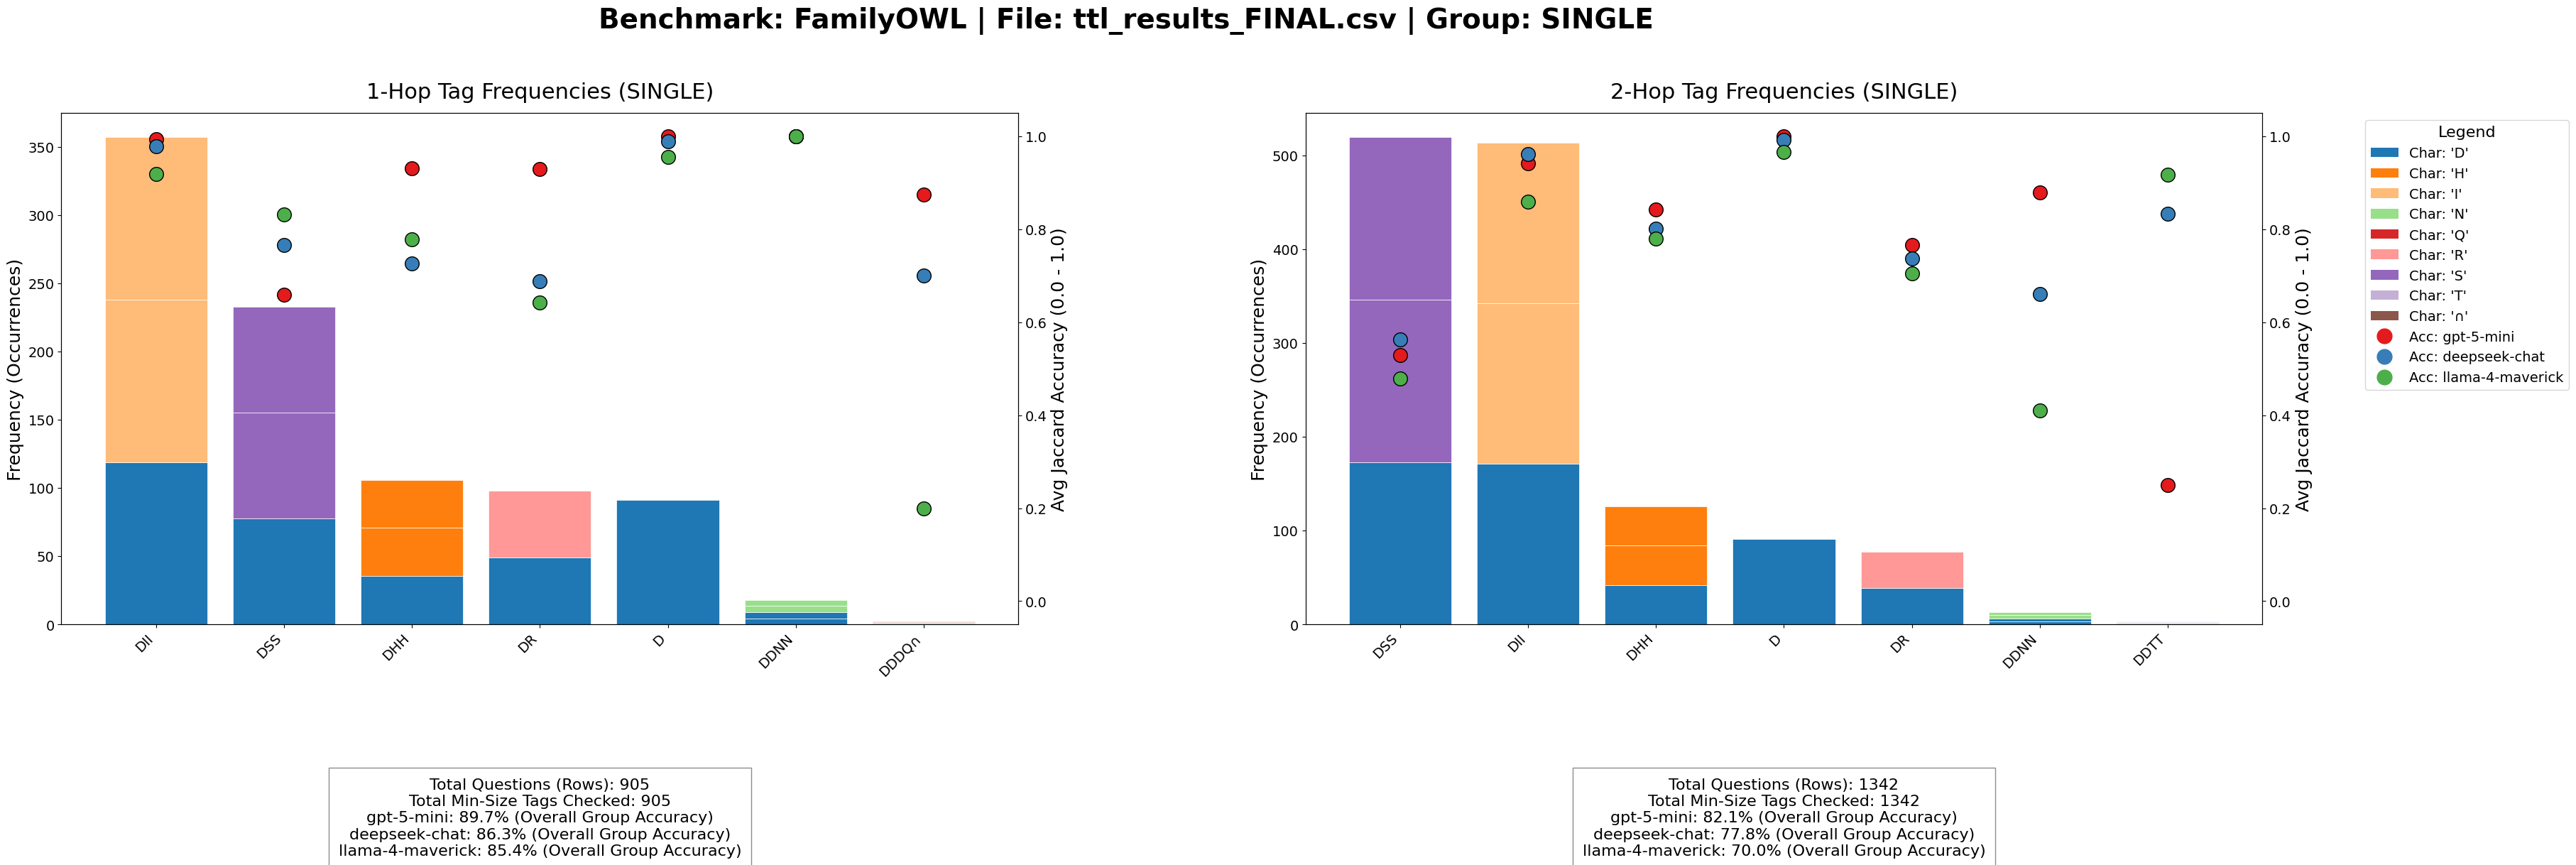

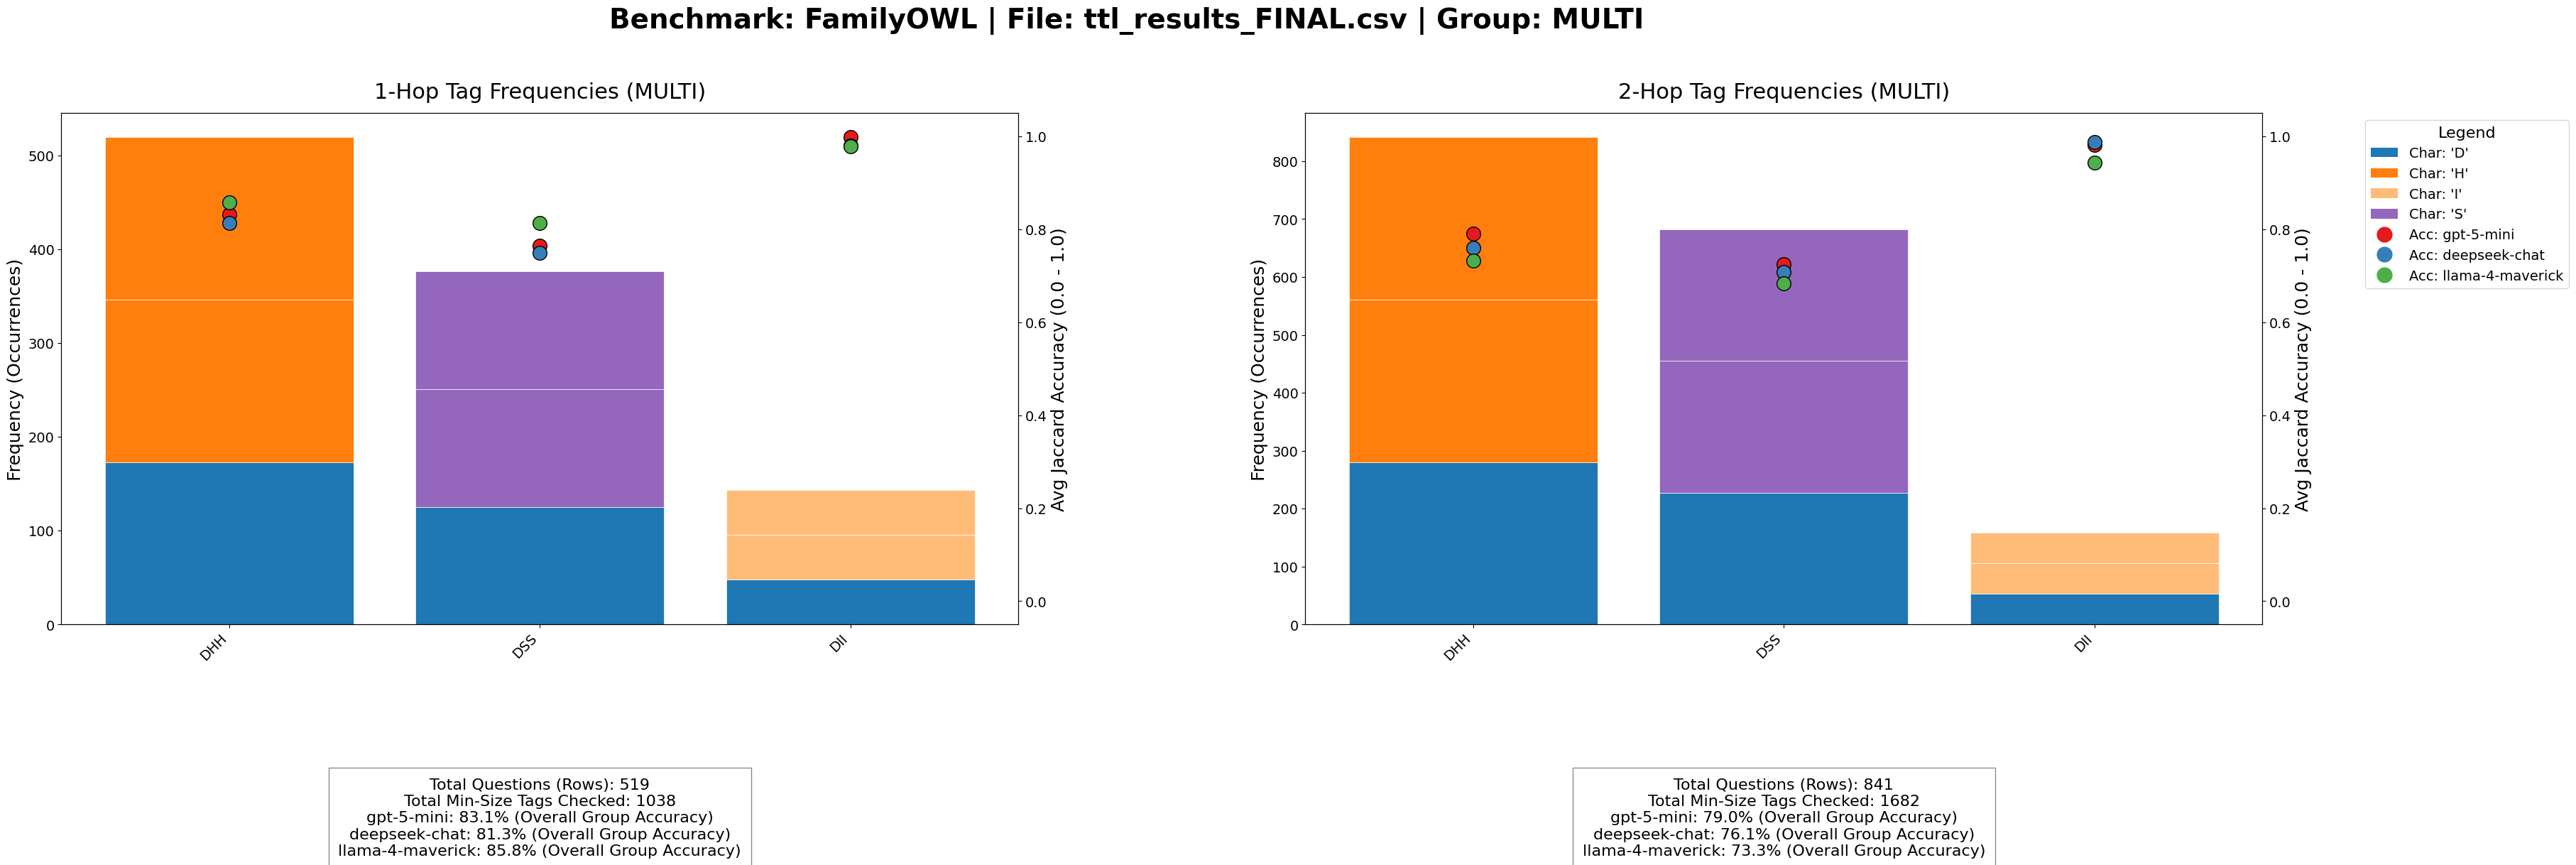

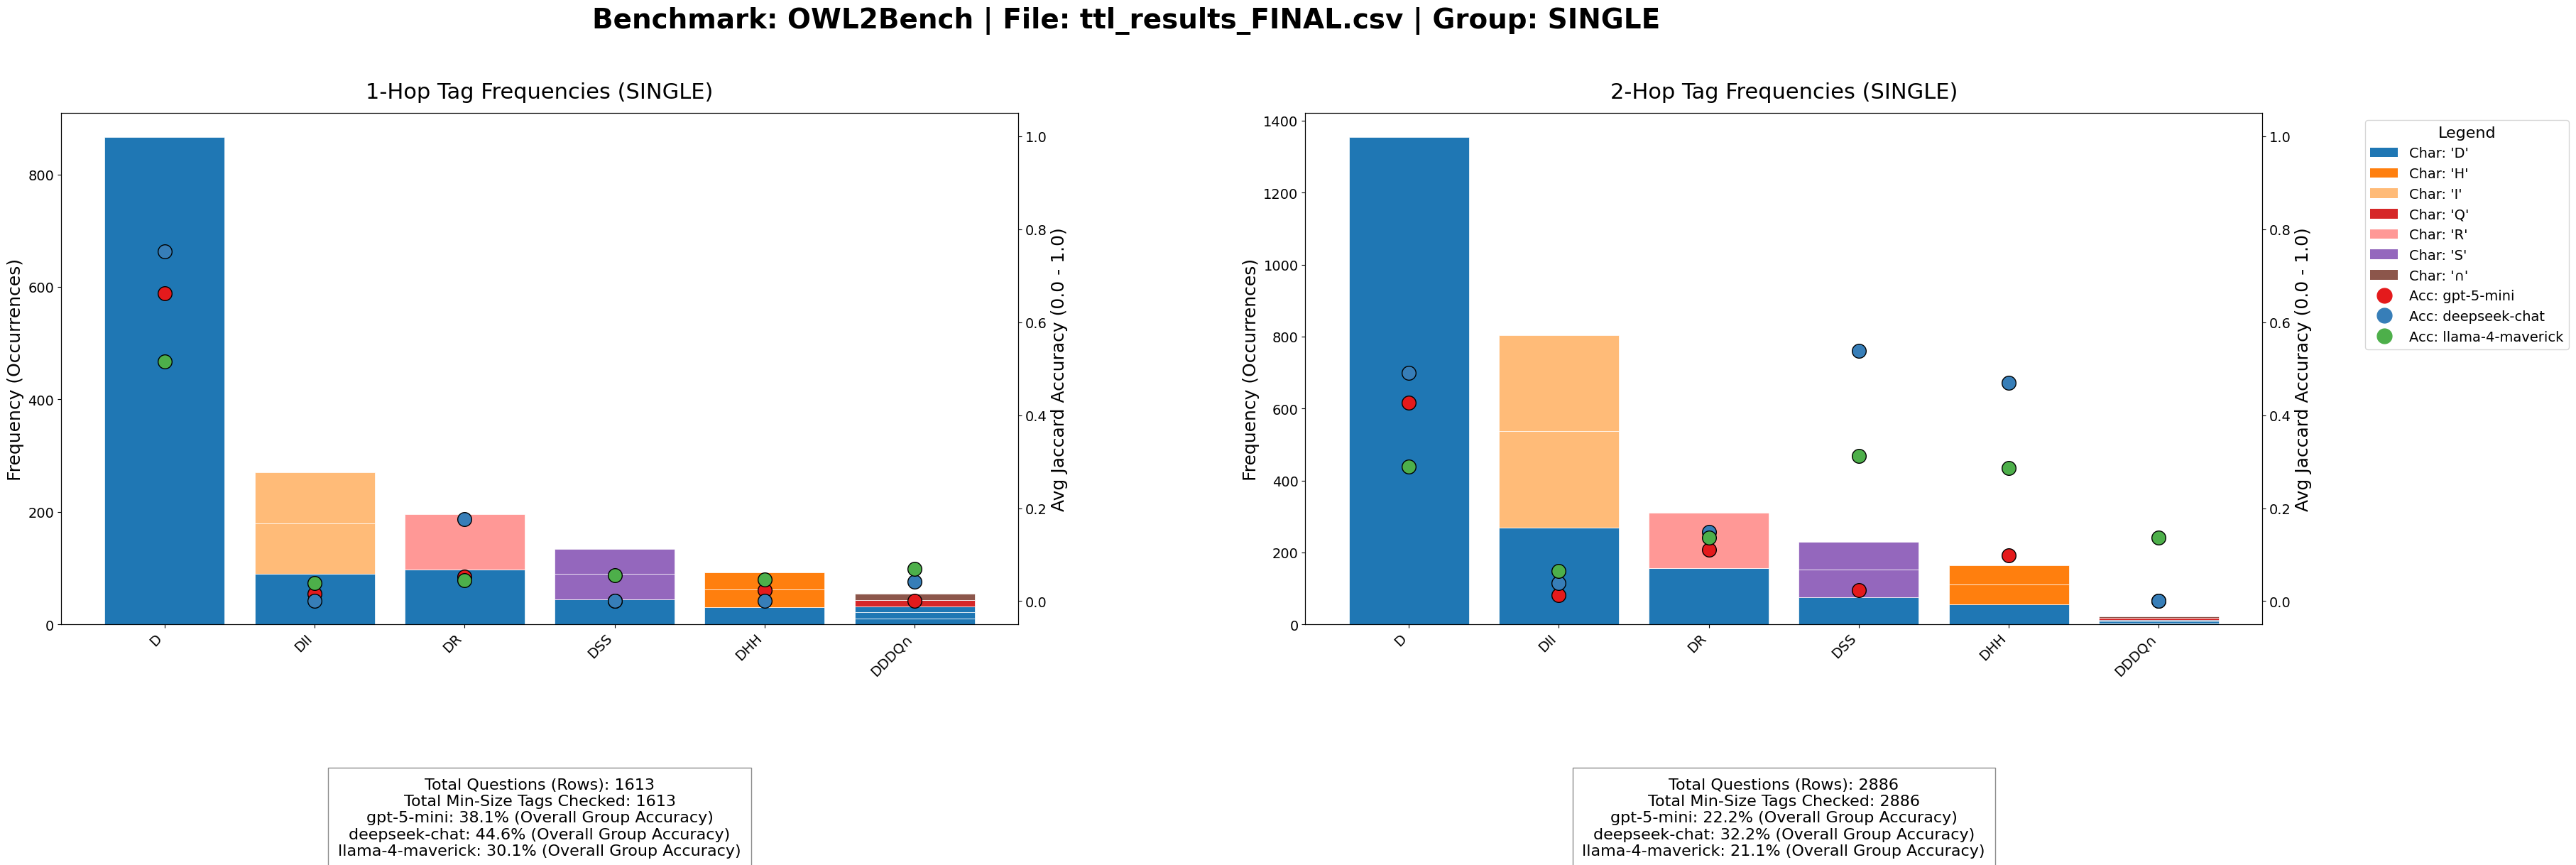

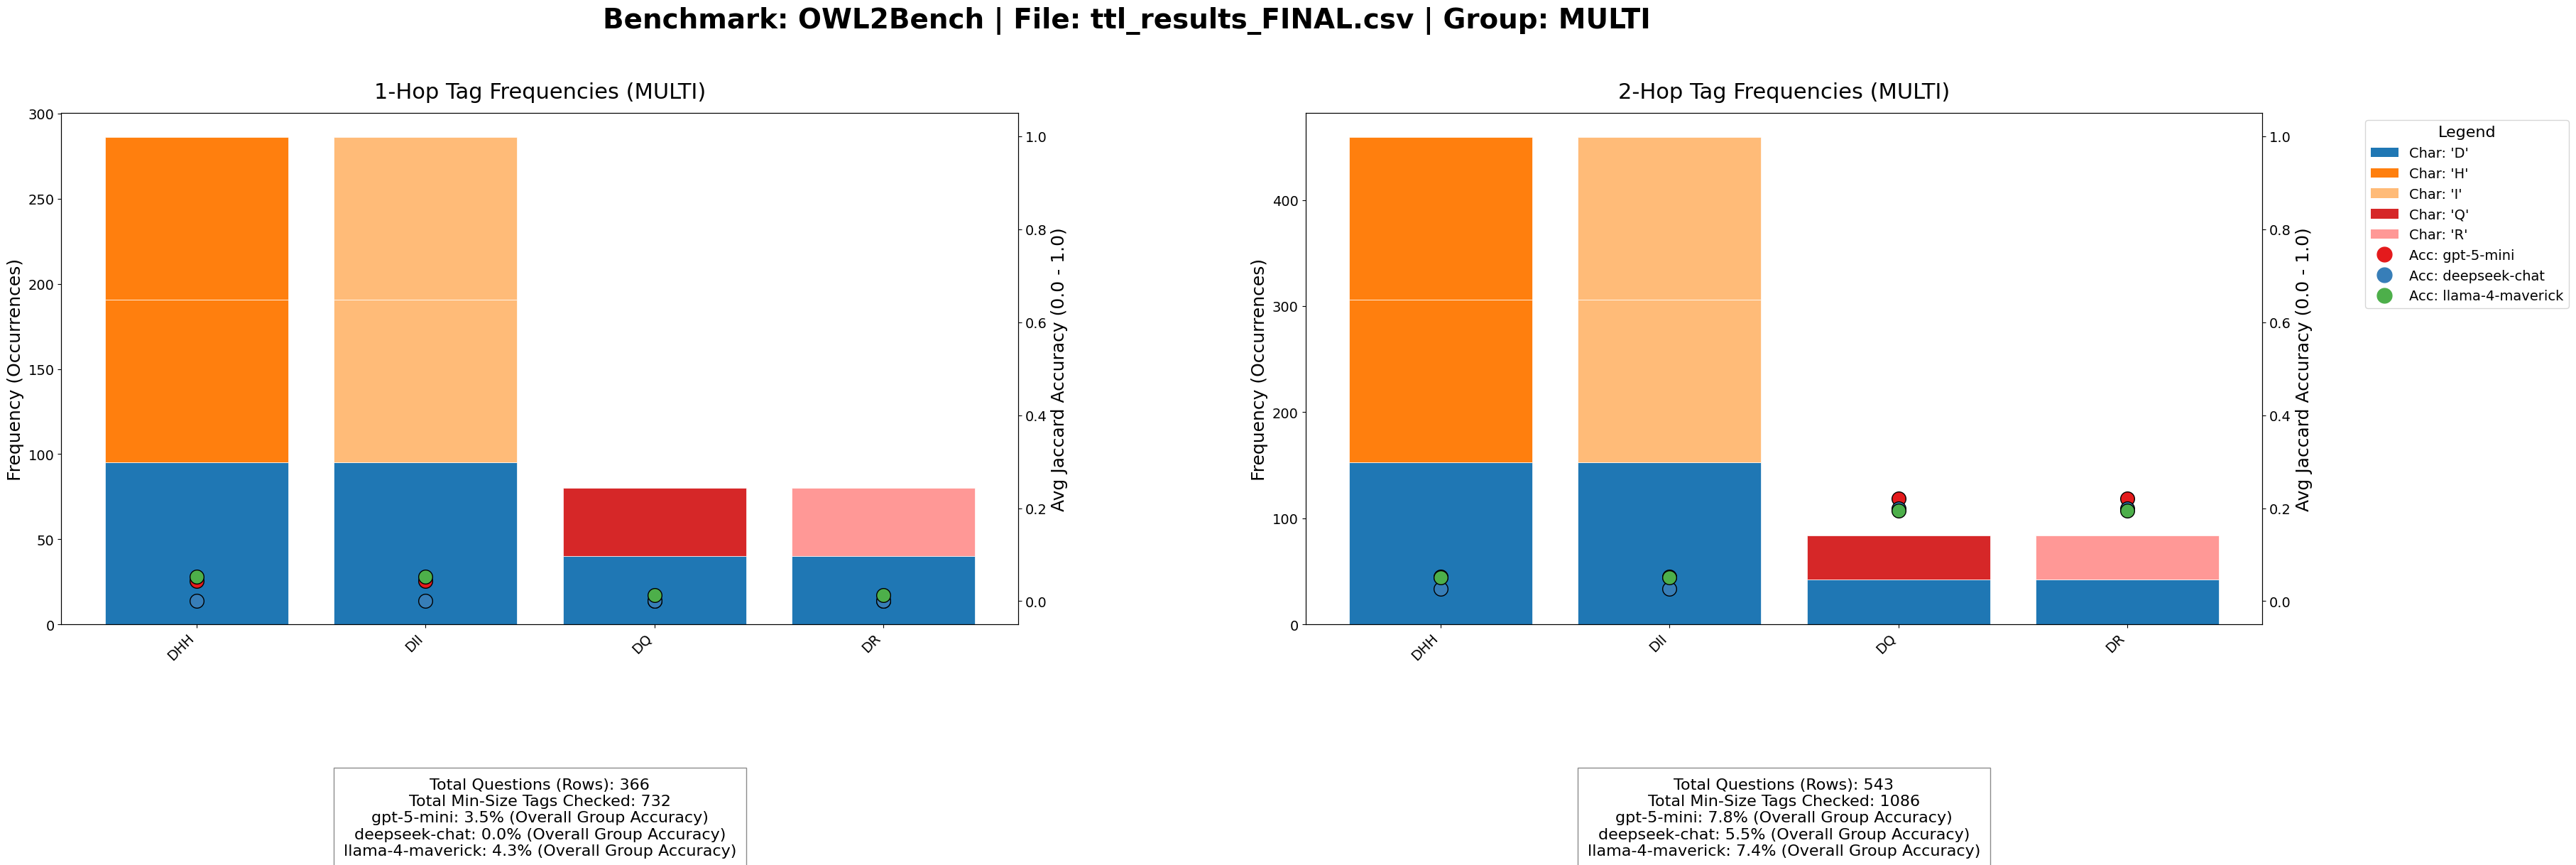

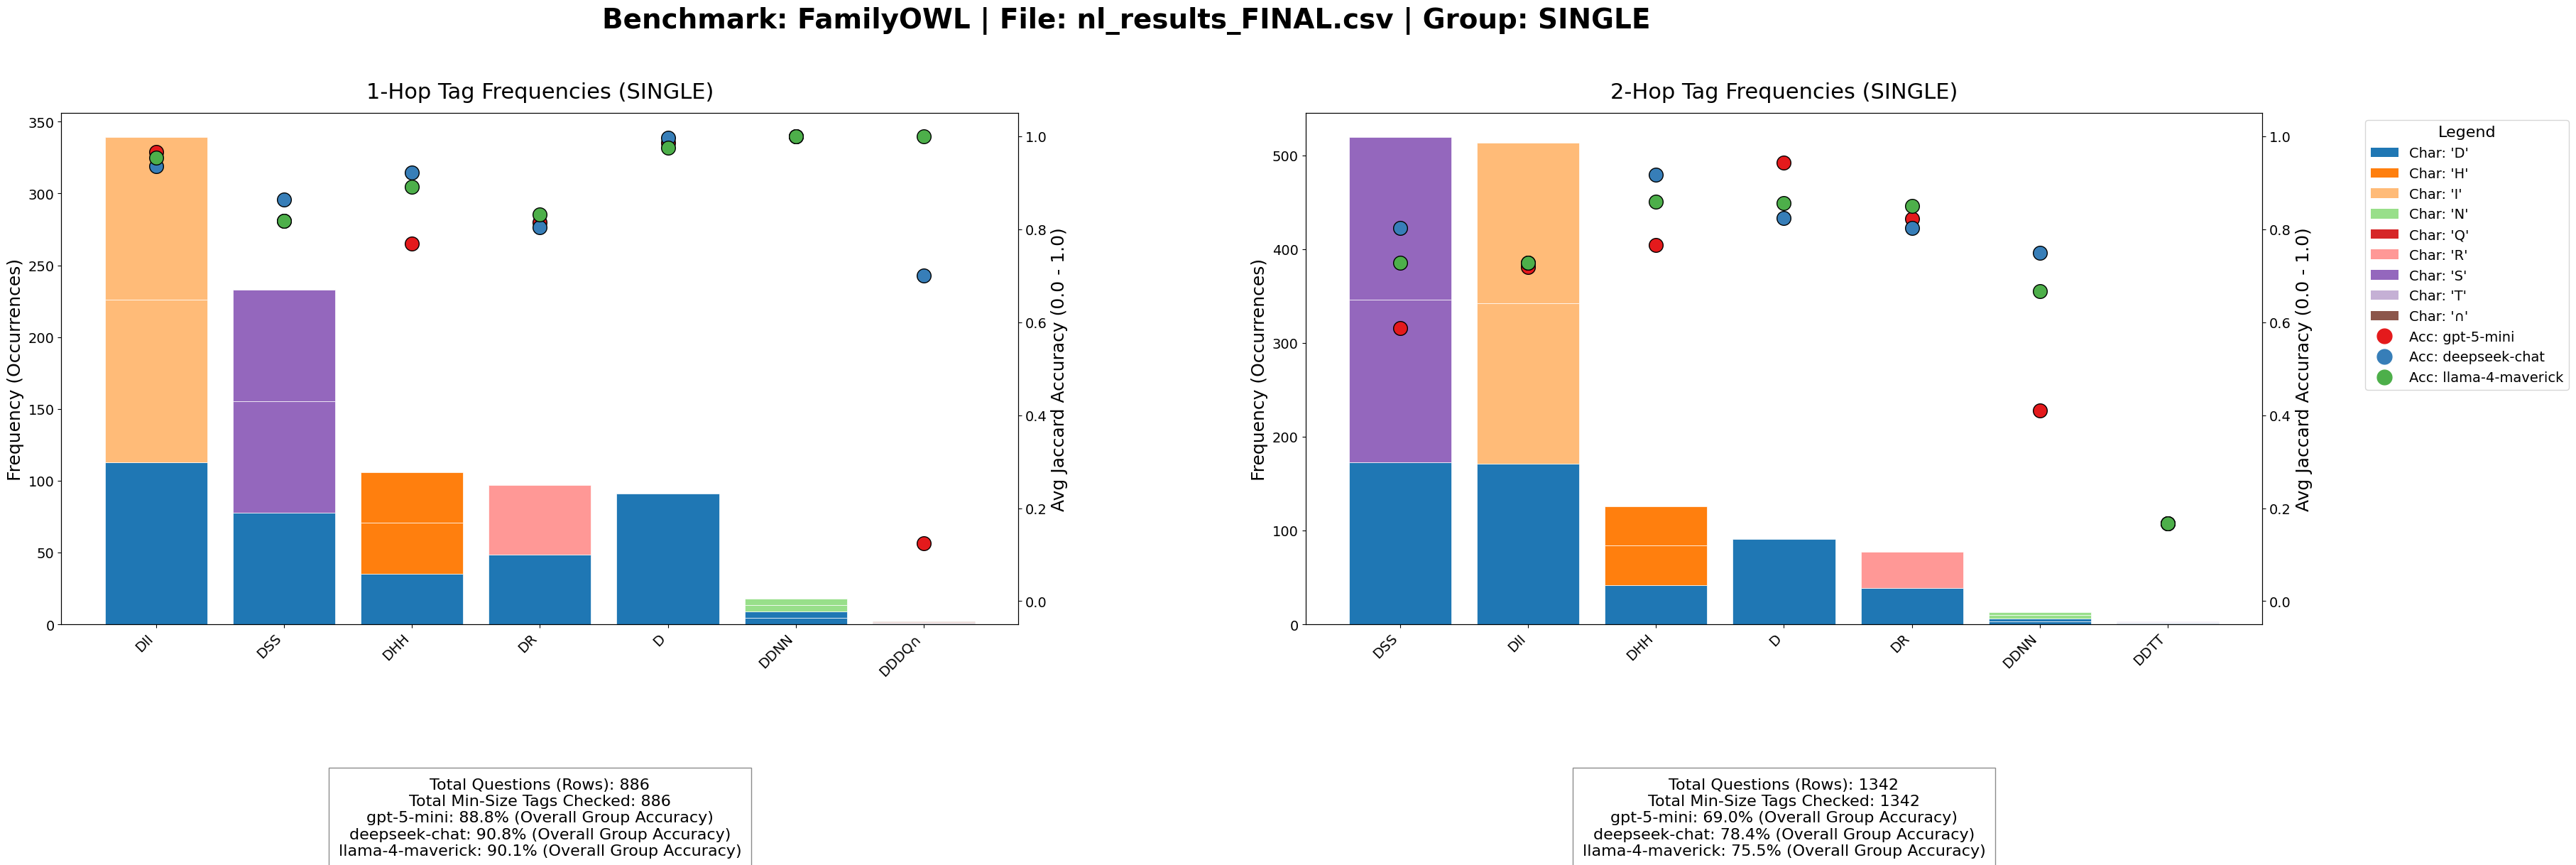

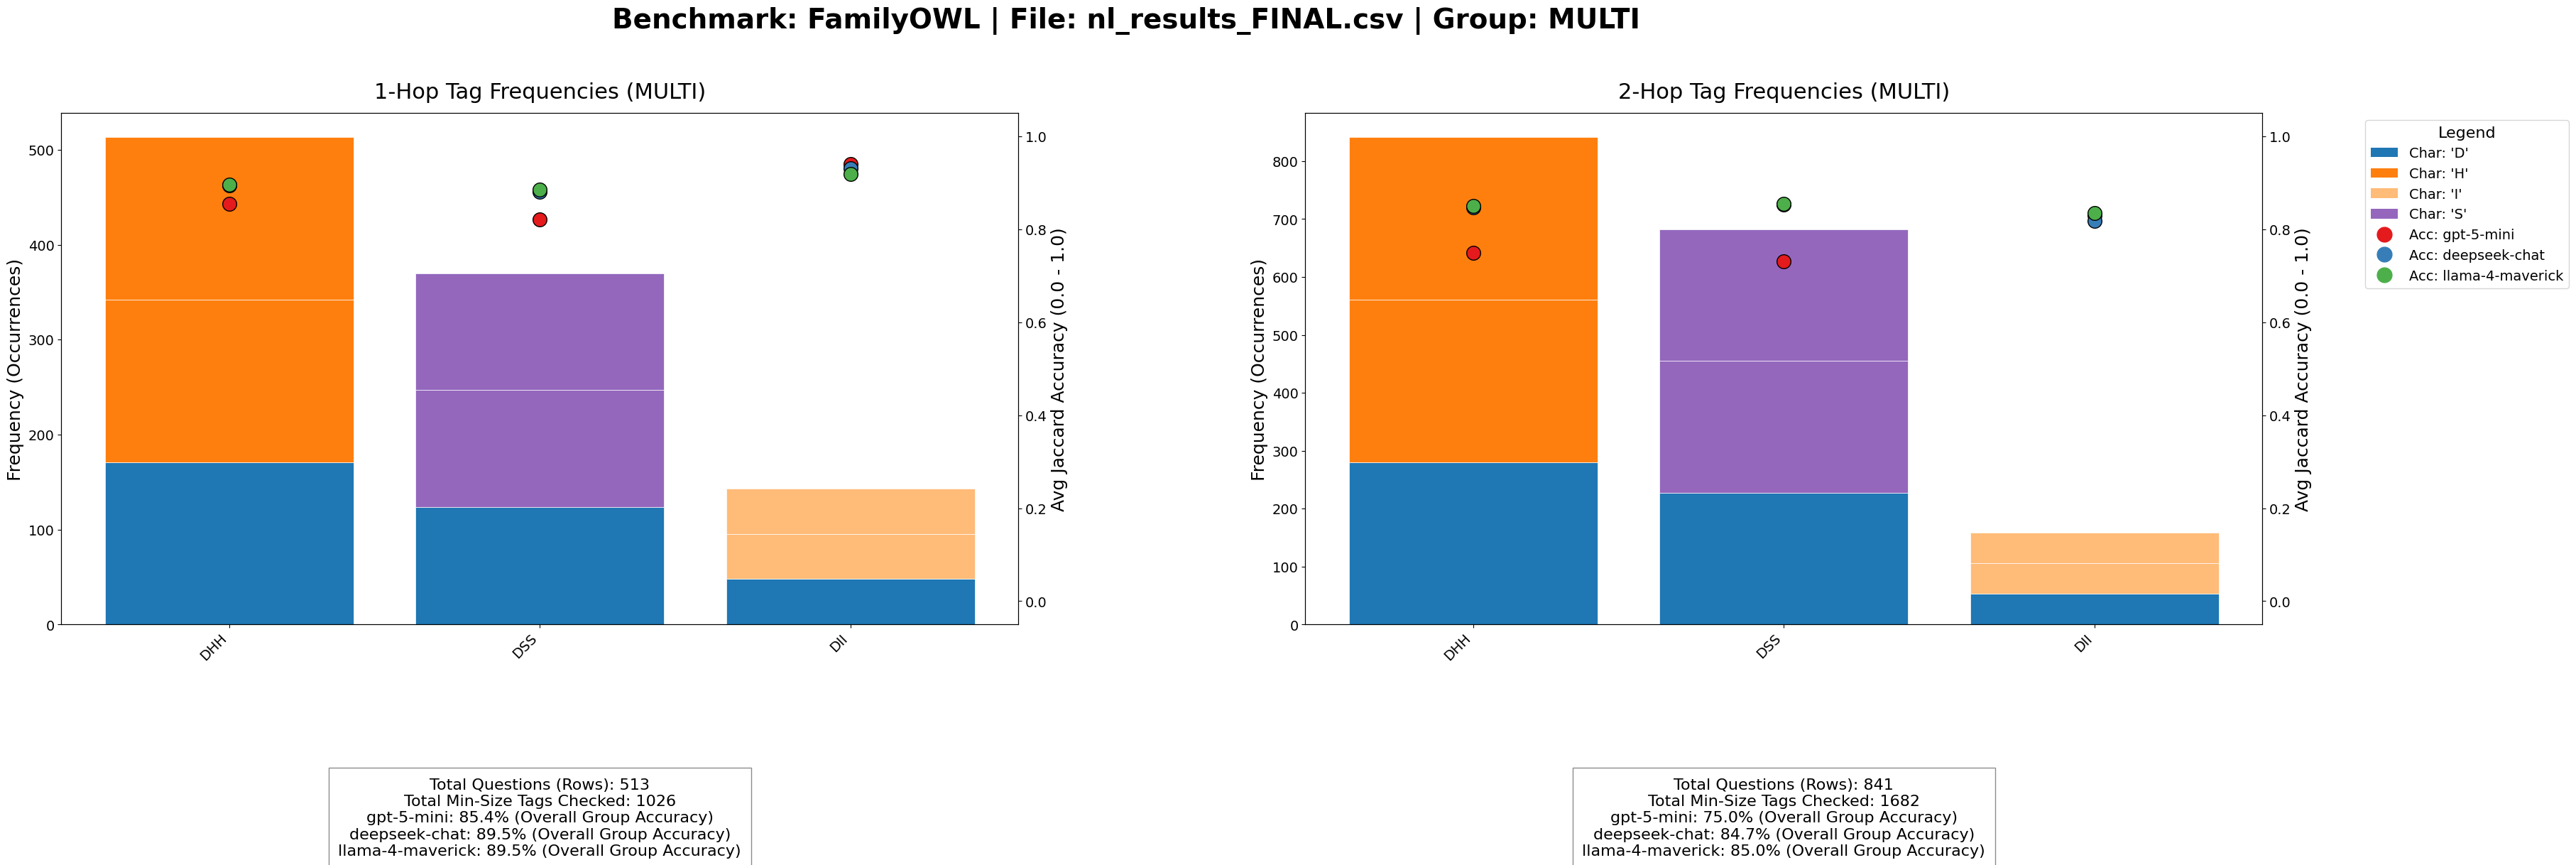

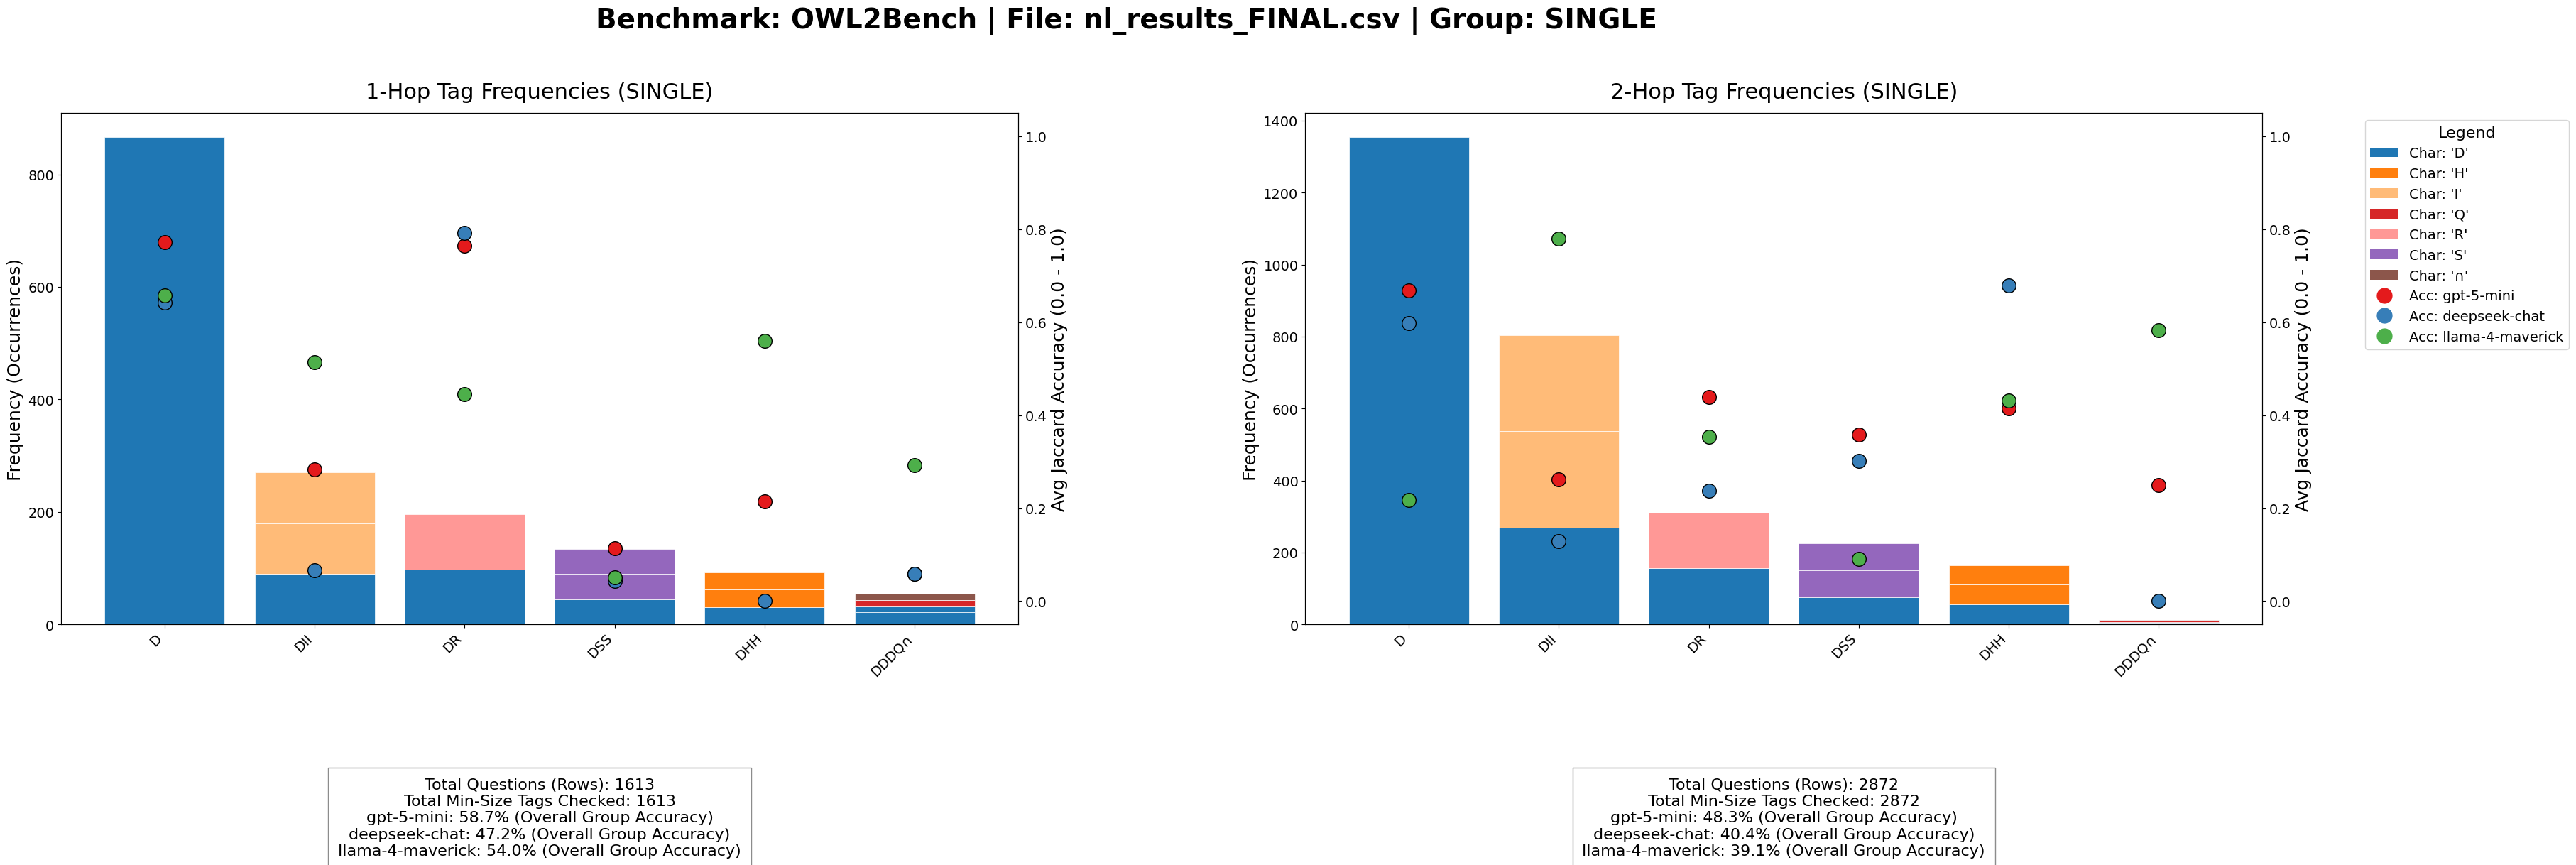

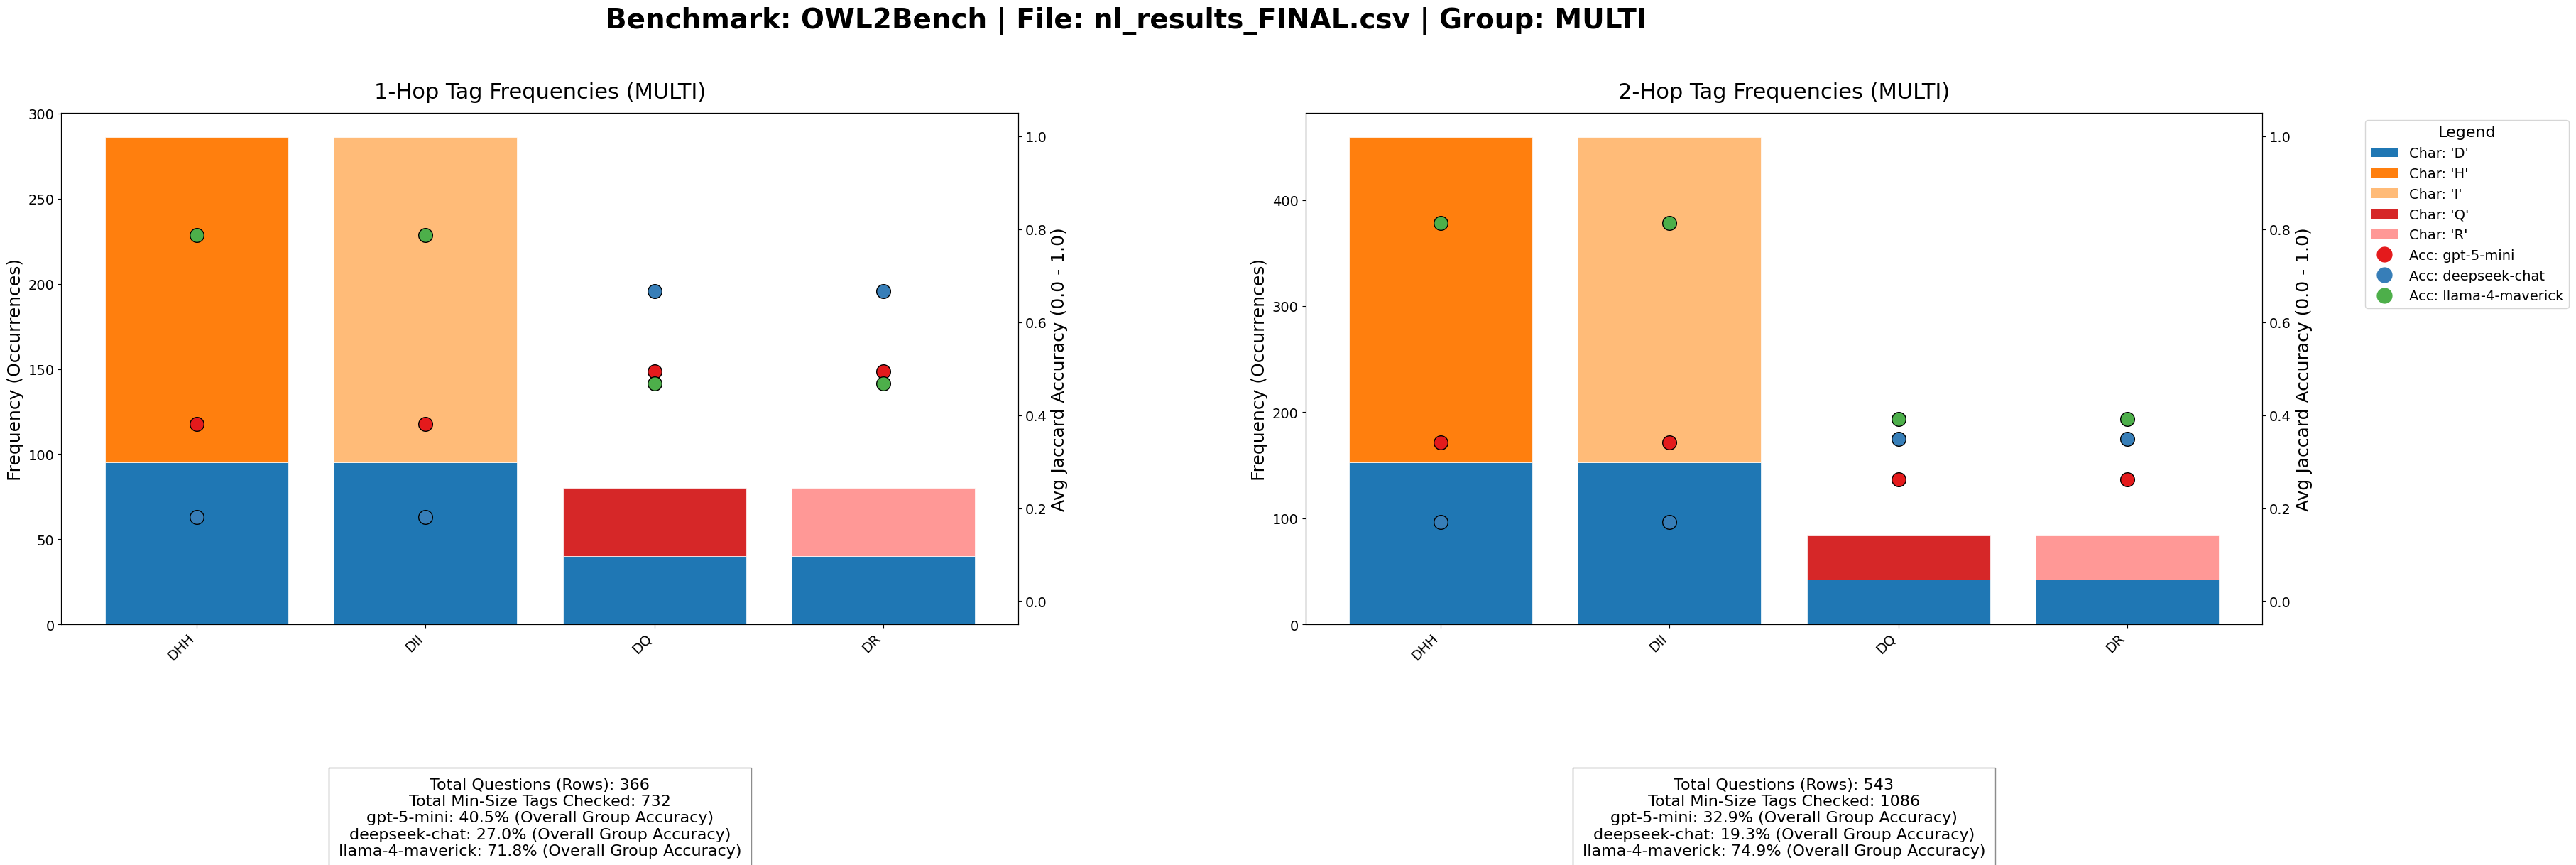

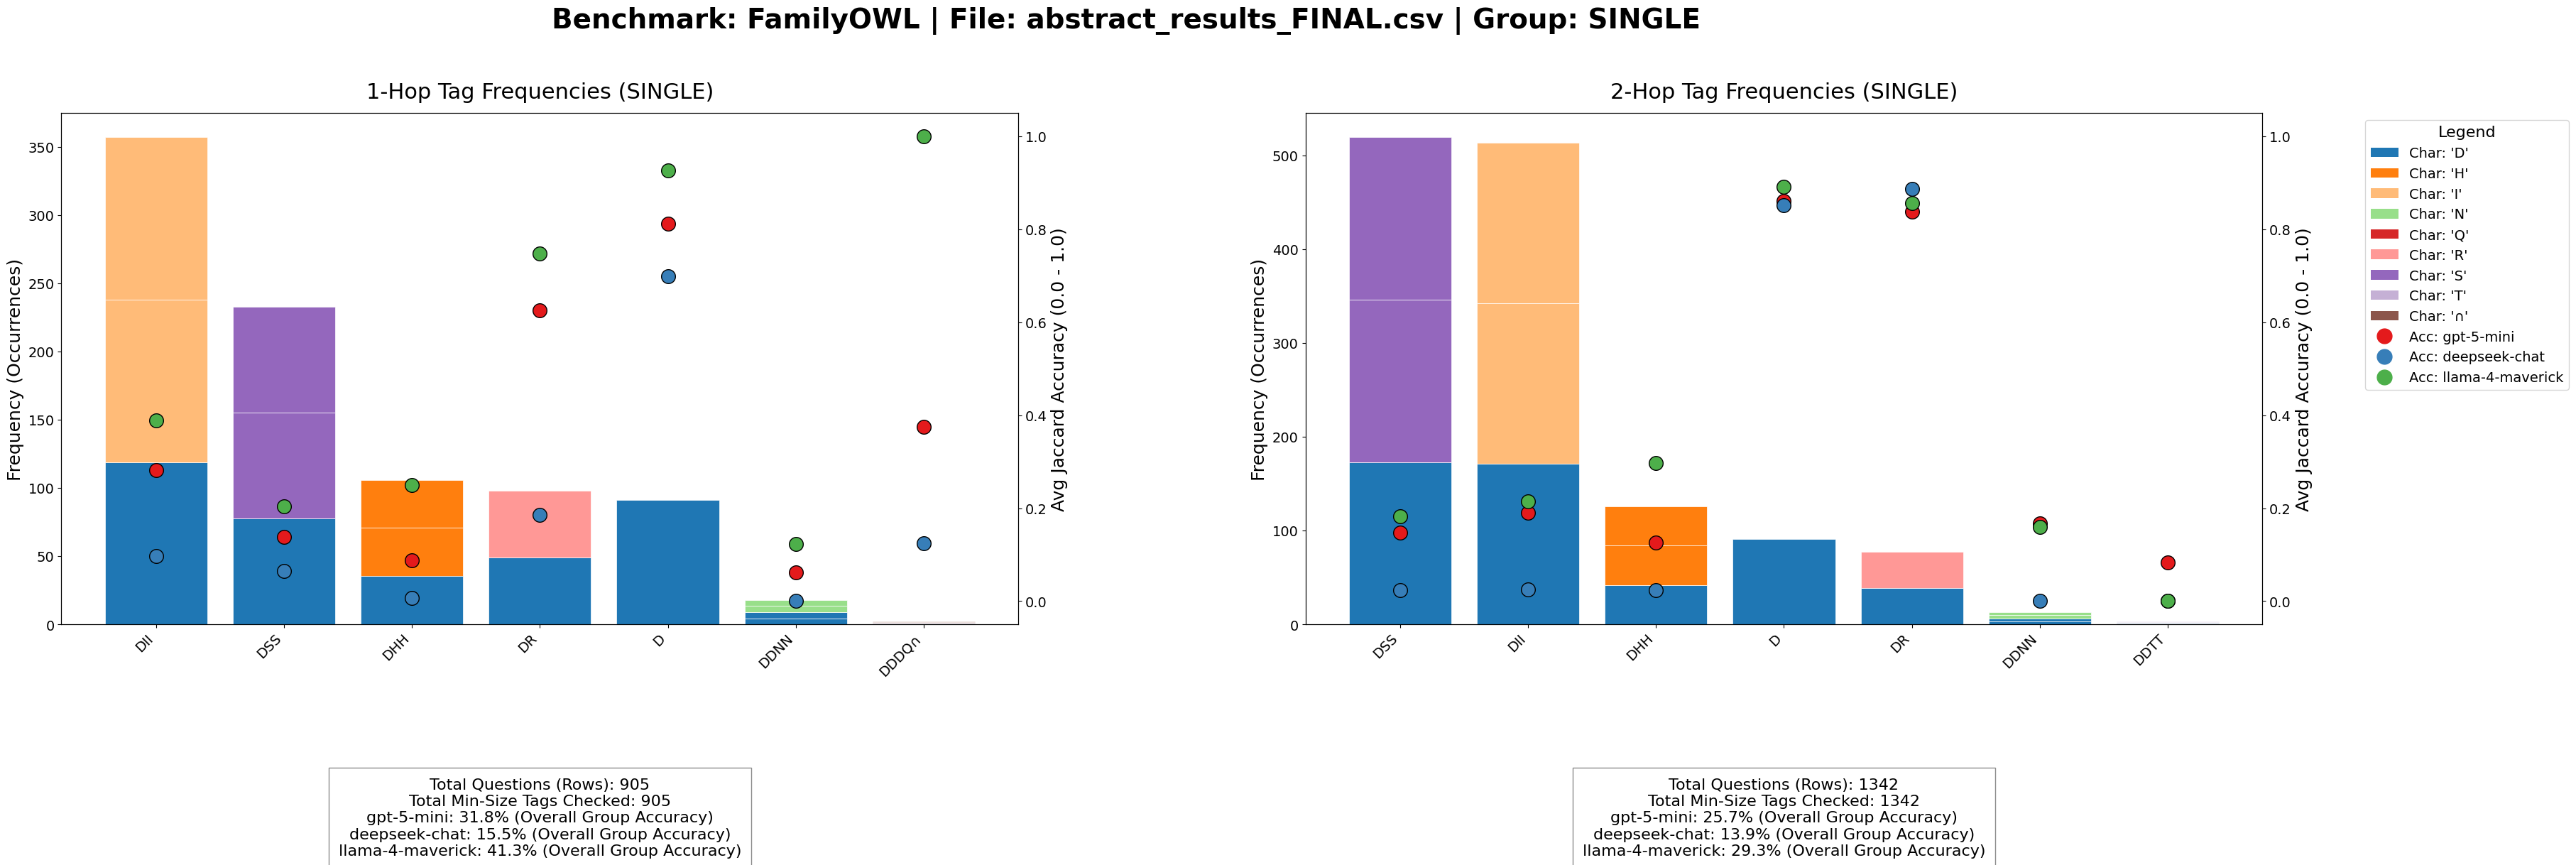

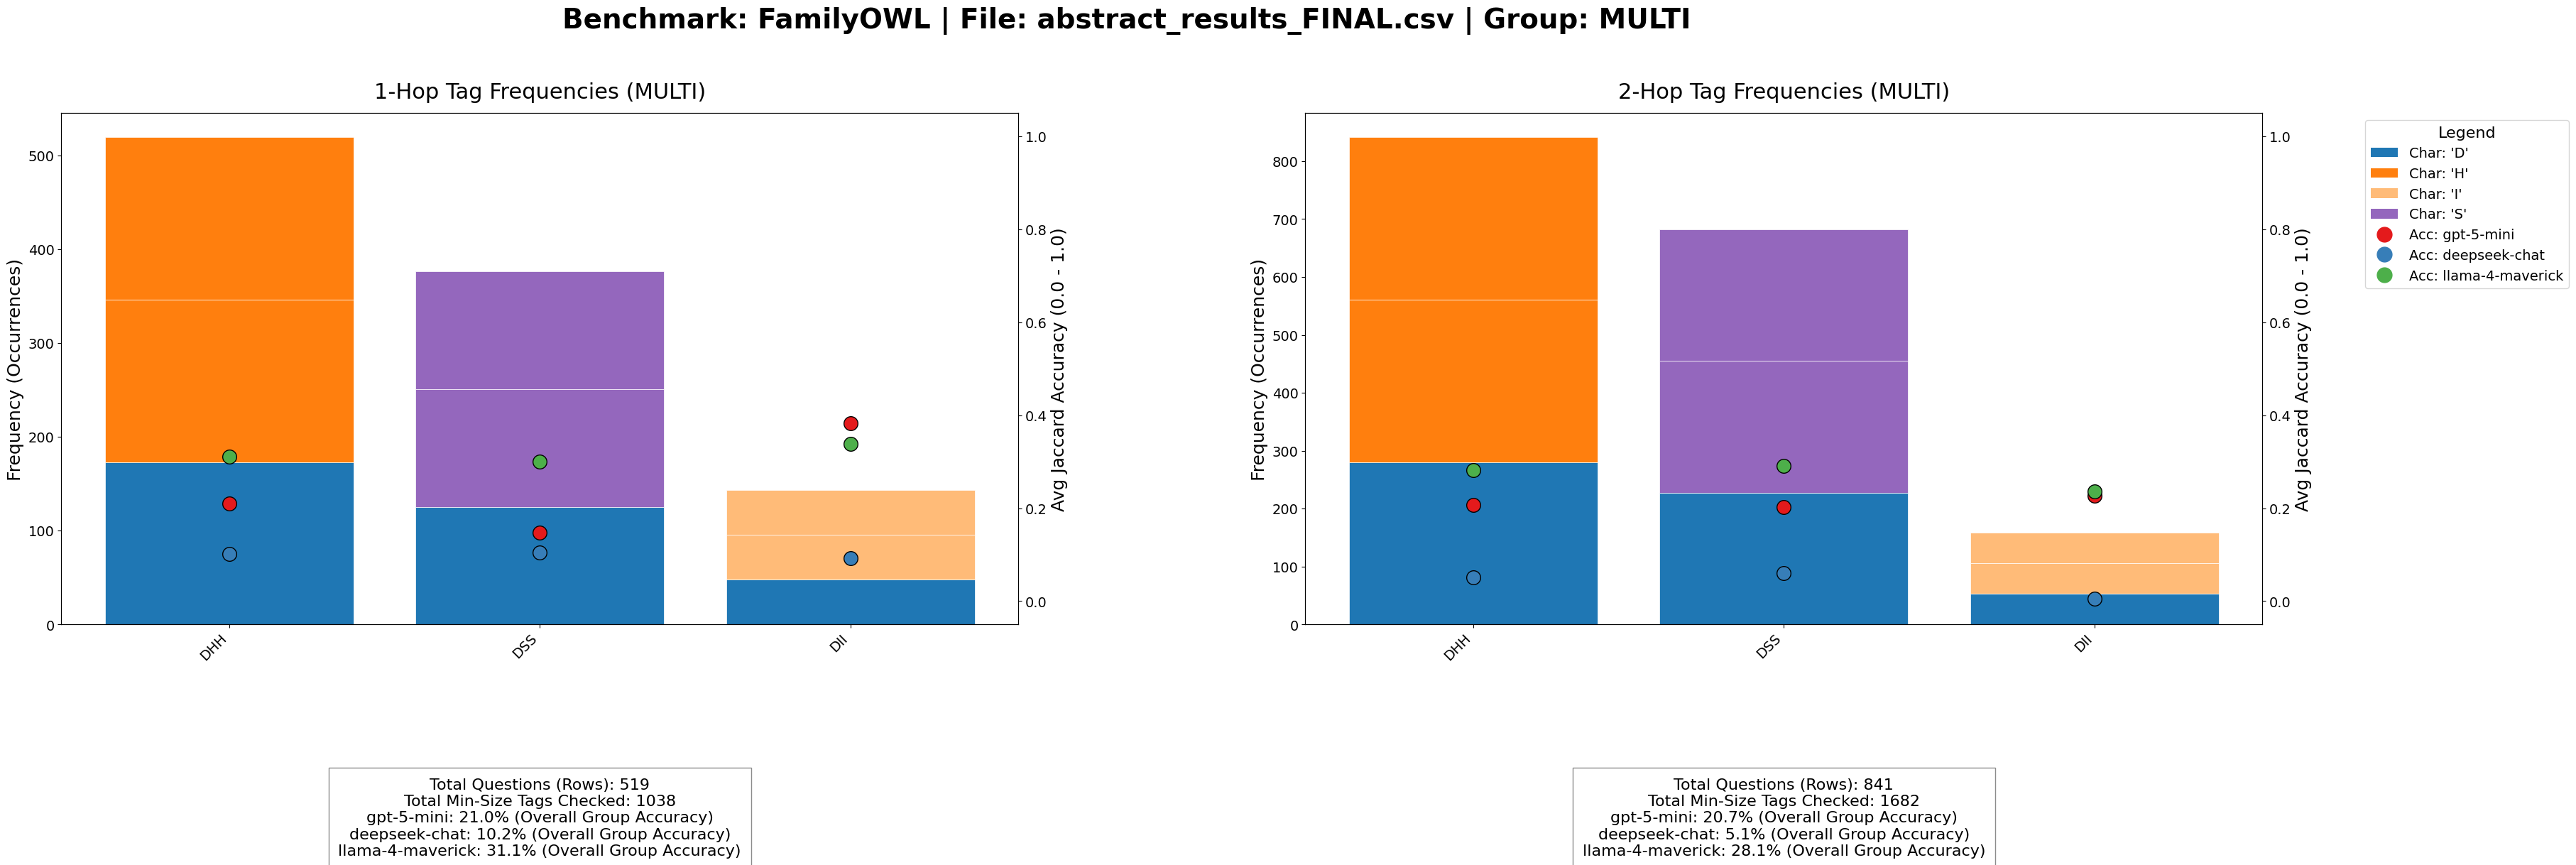

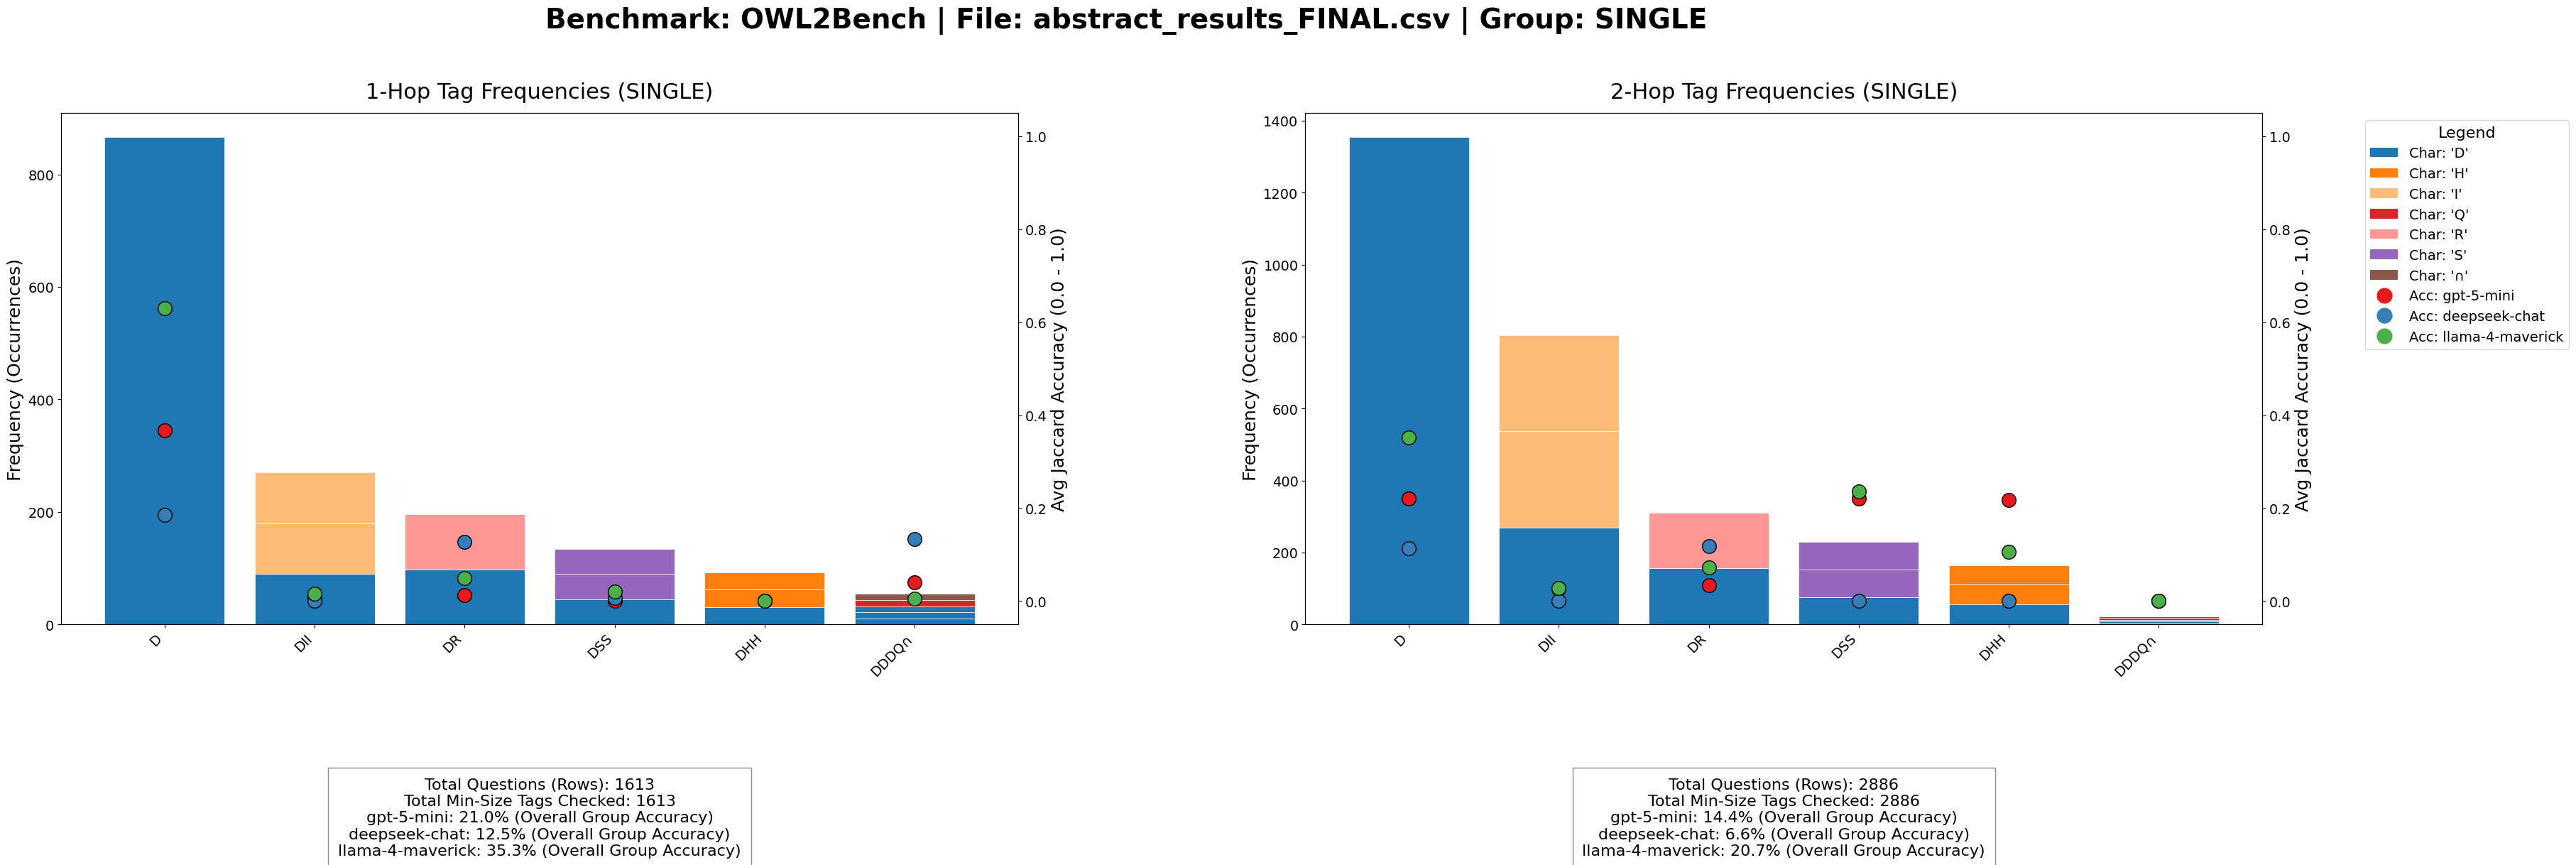

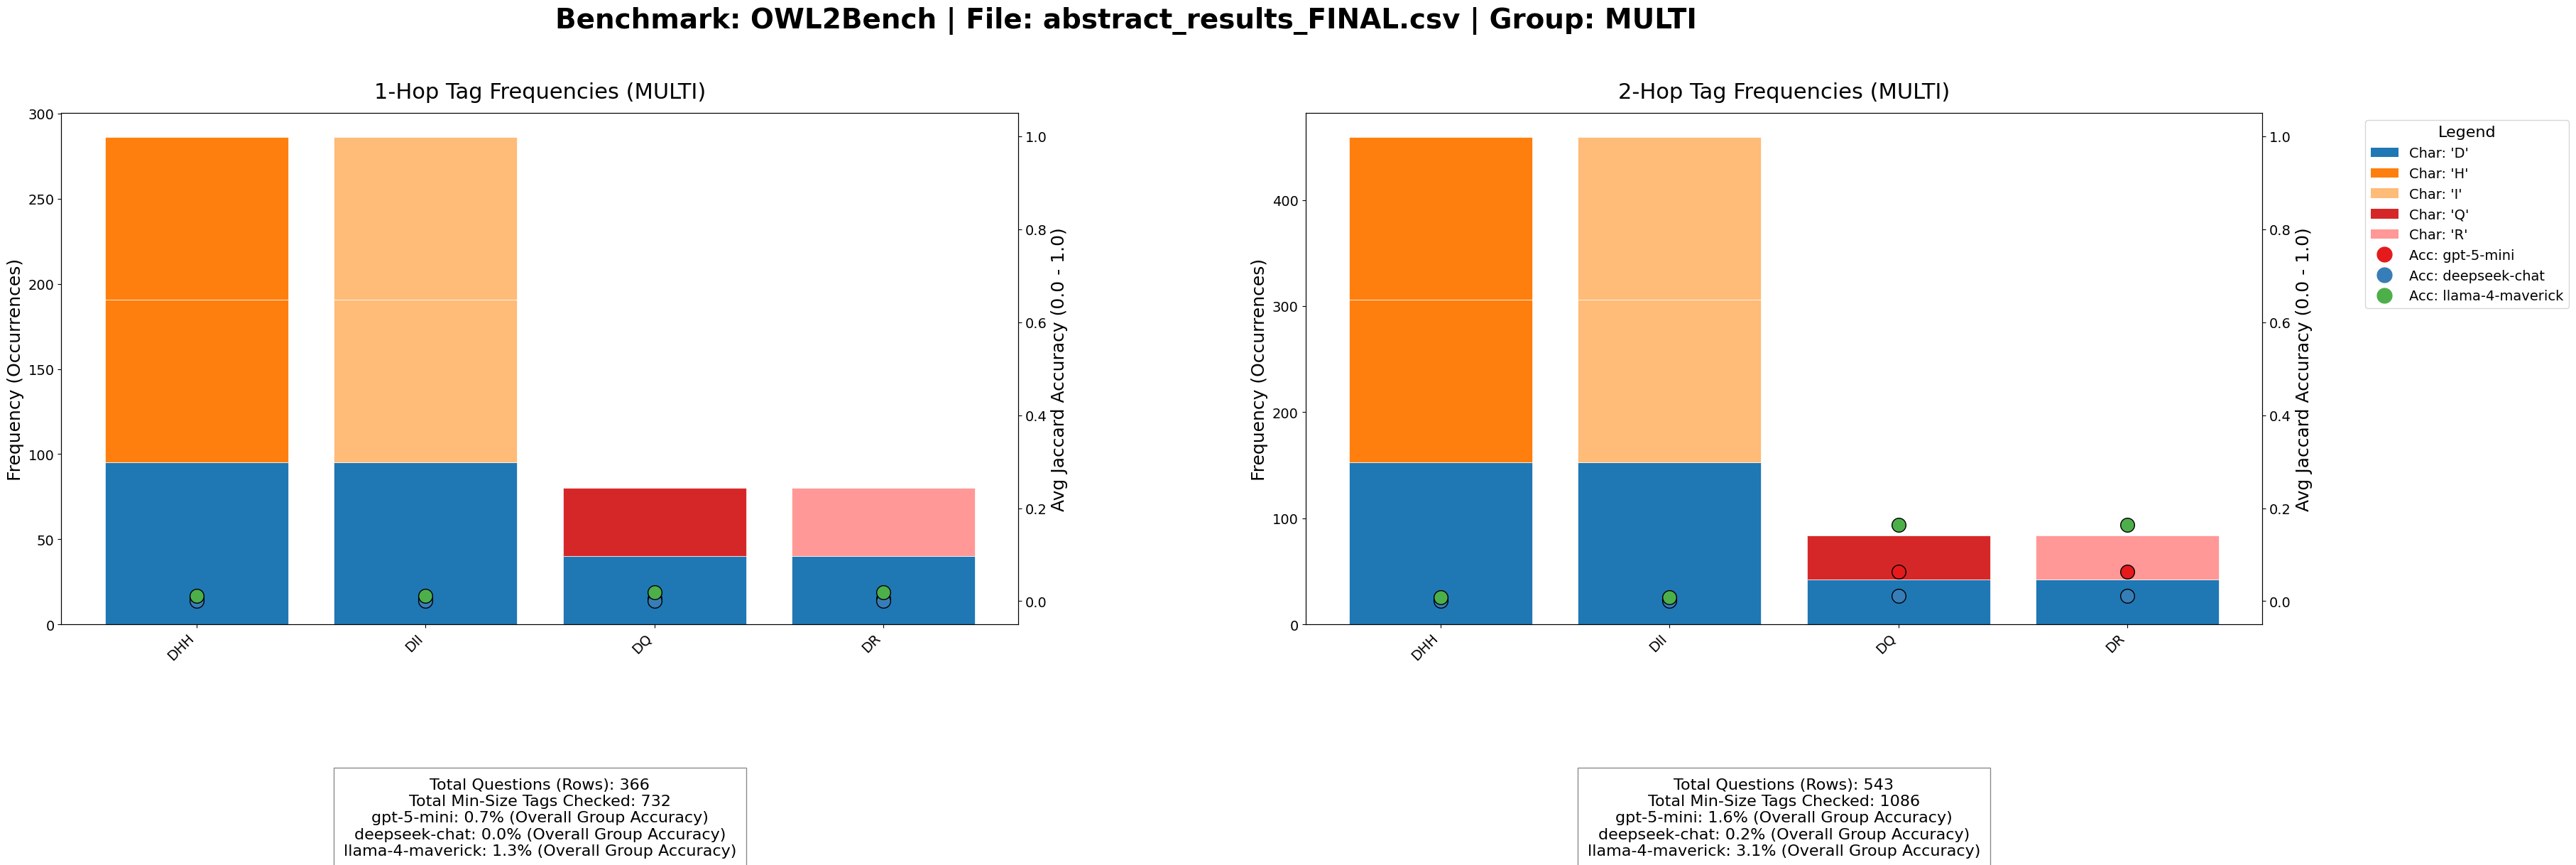

In [41]:
import os
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
base_dir = "../../" 

expl_files = [
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "output", "toy_example", "1hop", "Explanations.json"),

    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "output", "toy_example", "1hop", "Explanations.json"),

    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "output", "toy_example", "1hop", "Explanations.json"),
]

csv_files = [
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "toy_example_1hop", "ttl_results_FINAL.csv"),

    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "toy_example_1hop", "nl_results_FINAL.csv"),

    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "toy_example_1hop", "abstract_results_FINAL.csv"),
]

downloads_dir = os.path.abspath(os.path.expanduser("~/Downloads"))
os.makedirs(downloads_dir, exist_ok=True)

# --- HELPER FUNCTIONS ---

def clean_answer(text):
    if pd.isna(text):
        return set()
    text = str(text).strip().lower()
    parts = re.split(r'[;,]', text)
    cleaned_set = set()
    for part in parts:
        part = re.sub(r'[_*#@$%^&()+={\[\]}\|\\:;"\'<>?/~`]', '', part)
        part = re.sub(r'\s\d{4}$', '', part)
        part = re.sub(r'\b\d+\b', '', part)
        part = re.sub(r'[^a-z0-9\s]', '', part)
        part = part.strip()
        if part:
            cleaned_set.add(part)
    return cleaned_set

def get_jaccard_score(expected, actual, q_type="MC"):
    set_expected = clean_answer(expected)
    set_actual = clean_answer(actual)
    if not set_expected and not set_actual:
        return 0.0
    intersection = len(set_expected.intersection(set_actual))
    union = len(set_expected.union(set_actual))
    if union == 0: return 0.0
    score = intersection / union
    if q_type == "BIN":
        return 1.0 if score == 1.0 else 0.0
    return score

def load_explanations(filepath):
    task_classification = {}
    task_minimal_tags = {}
    if not os.path.exists(filepath):
        return task_classification, task_minimal_tags
        
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    task_to_tags = defaultdict(list)
    for tkey, details in data.items():
        task_ids = details.get("taskIds", [])
        explanations = details.get("explanations", [])
        
        for exp_list in explanations:
            for item in exp_list:
                if isinstance(item, str) and item.startswith("TAG:"):
                    clean_tag = item.replace("TAG:", "")
                    for tid in task_ids:
                        task_to_tags[str(tid).strip()].append(clean_tag)
                        
    for tid, tags in task_to_tags.items():
        if not tags:
            task_minimal_tags[tid] = []
            task_classification[tid] = "single"
            continue
            
        unique_tags = set(tags)
        min_char_len = min(len(t) for t in unique_tags)
        shortest_tags = [t for t in unique_tags if len(t) == min_char_len]
        
        task_minimal_tags[tid] = shortest_tags
        task_classification[tid] = "multi" if len(shortest_tags) > 1 else "single"
        
    return task_classification, task_minimal_tags

# --- PHASE 0: PRE-PASS FOR GLOBAL COLOR CONSISTENCY ---
print("Scanning datasets for character palette initialization...")
global_chars = set()
for f_path in set(expl_files):
    if os.path.exists(f_path):
        with open(f_path, 'r', encoding='utf-8') as f:
            try:
                d = json.load(f)
                for item in d.values():
                    for el in item.get("explanations", []):
                        for string_val in el:
                            if isinstance(string_val, str) and string_val.startswith("TAG:"):
                                global_chars.update(string_val.replace("TAG:", ""))
            except Exception:
                pass

sorted_global_chars = sorted(list(global_chars))
global_cmap = plt.colormaps['tab20']
global_char_to_color = {char: global_cmap(i % 20) for i, char in enumerate(sorted_global_chars)}

# --- MAIN LOOP ---
grouped_tasks = defaultdict(list)
for csv_file, expl_file in zip(csv_files, expl_files):
    if "toy_example" in csv_file:
        continue
        
    parent_dir = os.path.basename(os.path.dirname(csv_file))
    csv_name = os.path.basename(csv_file)
    bench_base = re.sub(r'_[12]hop', '', parent_dir)
    hop_match = re.search(r'([12])hop', parent_dir)
    hop_num = int(hop_match.group(1)) if hop_match else 1
    grouped_tasks[(bench_base, csv_name)].append((hop_num, csv_file, expl_file))

for (bench_base, csv_name), tasks in grouped_tasks.items():
    tasks.sort(key=lambda x: x[0]) 
    
    for split_group in ['single', 'multi']:
        fig, axes = plt.subplots(1, len(tasks), figsize=(40, 15), squeeze=False)
        fig.suptitle(f"Benchmark: {bench_base} | File: {csv_name} | Group: {split_group.upper()}", fontsize=28, fontweight='bold', y=0.98)
        
        all_unique_chars = set()
        all_model_colors = {}
        profile_model_accs = defaultdict(dict)

        for idx, (hop_num, csv_file, expl_file) in enumerate(tasks):
            ax1 = axes[0, idx]
            filename = os.path.abspath(csv_file)
            
            if not os.path.exists(csv_file) or not os.path.exists(expl_file):
                ax1.set_title(f"{hop_num}-Hop: Files Missing", fontsize=20)
                ax1.axis('off')
                continue
            
            task_classification, task_minimal_tags = load_explanations(expl_file)
            
            try:
                df = pd.read_csv(csv_file, dtype=str)
                if 'Task ID' not in df.columns: 
                    ax1.axis('off')
                    continue
                
                df['Task ID'] = df['Task ID'].astype(str).str.strip()
                
                # Assign groups at the individual row level. Default to 'single' if missing from JSON.
                df['Group'] = df['Task ID'].apply(lambda x: task_classification.get(x, 'single'))
                df_group = df[df['Group'] == split_group]
                
                if df_group.empty:
                    ax1.set_title(f"{hop_num}-Hop: No Data for {split_group}", fontsize=20)
                    ax1.axis('off')
                    continue
                
                correctness_cols = [col for col in df.columns if col.endswith('_quality_correctness')]
                if not correctness_cols:
                    ax1.axis('off')
                    continue

                # Process frequencies globally across every row instance
                plot_tag_frequencies = defaultdict(int)
                total_min_tags_checked = 0
                
                for _, row in df_group.iterrows():
                    tid = row['Task ID']
                    tags_for_tid = task_minimal_tags.get(tid, [])
                    total_min_tags_checked += len(tags_for_tid)
                    for t in tags_for_tid:
                        plot_tag_frequencies[t] += 1
                        
                sorted_tags = sorted(plot_tag_frequencies.keys(), key=lambda x: plot_tag_frequencies[x], reverse=True)
                frequencies = [plot_tag_frequencies[t] for t in sorted_tags]
                
                model_accuracies = {}
                weighted_acc_printout = {}
                
                for col in correctness_cols:
                    model_name = col.replace('_quality_correctness', '')
                    final_ans_col = f"{model_name}_final_answer"
                    
                    tag_totals = defaultdict(int)
                    tag_scores = defaultdict(float)
                    question_scores = {}
                    
                    for row_idx, row in df_group.iterrows():
                        tid = row['Task ID']
                        tags_for_this_task = task_minimal_tags.get(tid, [])
                        
                        if final_ans_col in df_group.columns and 'Answer' in df_group.columns:
                            prediction = str(row[final_ans_col]).strip()
                            if pd.isna(row[final_ans_col]) or prediction == "" or prediction.upper().startswith(("ERROR", "[ERROR]")):
                                continue
                            q_type = row.get('Question Type', 'MC')
                            score = get_jaccard_score(str(row['Answer']), prediction, q_type=q_type)
                        else:
                            corr = row[col]
                            if pd.isna(corr): continue
                            score = 1.0 if int(float(corr)) == 1 else 0.0
                            
                        question_scores[row_idx] = score # Unique key per row instance
                        for t in tags_for_this_task:
                            tag_totals[t] += 1
                            tag_scores[t] += score
                            
                    if sorted_tags:
                        model_accuracies[model_name] = [(tag_scores[t] / tag_totals[t] if tag_totals[t] > 0 else None) for t in sorted_tags]
                    else:
                        model_accuracies[model_name] = []
                        
                    weighted_acc_printout[model_name] = sum(question_scores.values()) / len(question_scores) if question_scores else 0.0

                for model_name, accs in model_accuracies.items():
                    for tag, acc in zip(sorted_tags, accs):
                        if acc is not None:
                            profile_model_accs[model_name][f"{hop_num}-Hop {tag}"] = acc

                ax1.grid(False)
                
                if sorted_tags:
                    unique_chars = sorted(list(set("".join(sorted_tags))))
                    all_unique_chars.update(unique_chars)
                    x_positions = range(len(sorted_tags))
                    
                    for x_pos, tag, freq in zip(x_positions, sorted_tags, frequencies):
                        num_chars = len(tag)
                        if num_chars == 0: continue
                        segment_height = freq / num_chars
                        current_bottom = 0
                        for char in tag:
                            ax1.bar(x_pos, segment_height, bottom=current_bottom, 
                                    color=global_char_to_color[char], edgecolor='white', 
                                    linewidth=0.5, width=0.8)
                            current_bottom += segment_height
                    
                    ax1.set_xticks(x_positions)
                    ax1.set_xticklabels(sorted_tags, rotation=45, ha='right', fontsize=14)
                else:
                    ax1.set_xticks([])
                    ax1.set_xticklabels([])

                ax1.set_ylabel('Frequency (Occurrences)', fontsize=18)
                ax1.set_title(f'{hop_num}-Hop Tag Frequencies ({split_group.upper()})', fontsize=22, pad=15)
                ax1.tick_params(axis='y', labelsize=14)
                
                ax2 = ax1.twinx()
                ax2.grid(False)
                
                model_cmap = plt.colormaps['Set1']
                model_colors = {m: model_cmap(i % 9) for i, m in enumerate(model_accuracies.keys())}
                all_model_colors.update(model_colors)
                
                if sorted_tags:
                    for model_name, accs in model_accuracies.items():
                        px = [x for x, a in zip(x_positions, accs) if a is not None]
                        py = [a for a in accs if a is not None]
                        ax2.scatter(px, py, color=model_colors[model_name], marker='o', 
                                    s=200, label=model_name, zorder=5, edgecolors='black')
                
                ax2.set_ylabel('Avg Jaccard Accuracy (0.0 - 1.0)', fontsize=18)
                ax2.set_ylim(-0.05, 1.05)
                ax2.tick_params(axis='y', labelsize=14)

                stats_str = f"Total Questions (Rows): {len(df_group)}\nTotal Min-Size Tags Checked: {total_min_tags_checked}\n" + "\n".join(
                    [f"{m}: {acc:.1%} (Overall Group Accuracy)" for m, acc in weighted_acc_printout.items()]
                )
                
                ax1.text(0.5, -0.30, stats_str, transform=ax1.transAxes, ha='center', va='top', 
                         fontsize=16, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', pad=10))

            except Exception as e:
                print(f"  -> Error parsing {filename}: {e}")
            
        plt.subplots_adjust(bottom=0.40, wspace=0.3)
        
        if all_unique_chars and all_model_colors:
            sorted_unique_chars = sorted(list(all_unique_chars))
            legend_elements = [Patch(facecolor=global_char_to_color[c], label=f"Char: '{c}'") for c in sorted_unique_chars]
            for model_name, color in all_model_colors.items():
                legend_elements.append(mlines.Line2D([], [], color=color, marker='o', 
                                                     linestyle='None', markersize=15, label=f'Acc: {model_name}'))
            
            axes[0, -1].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.1, 1.0), 
                               title="Legend", fontsize=14, title_fontsize=16)

        clean_csv_suffix = csv_name.replace('_FINAL.csv', f'_{split_group}_results_final.png').lower()
        target_output_name = f"{bench_base}_{clean_csv_suffix}"
        full_export_path = os.path.join(downloads_dir, target_output_name)
        
        plt.savefig(full_export_path, dpi=150, bbox_inches='tight')
        plt.show()

Data Collection Complete. Collected 94408 row observations.
Running baseline rotation loops for Ontology: FAMILYOWL (SINGLE | 1-Hop)...


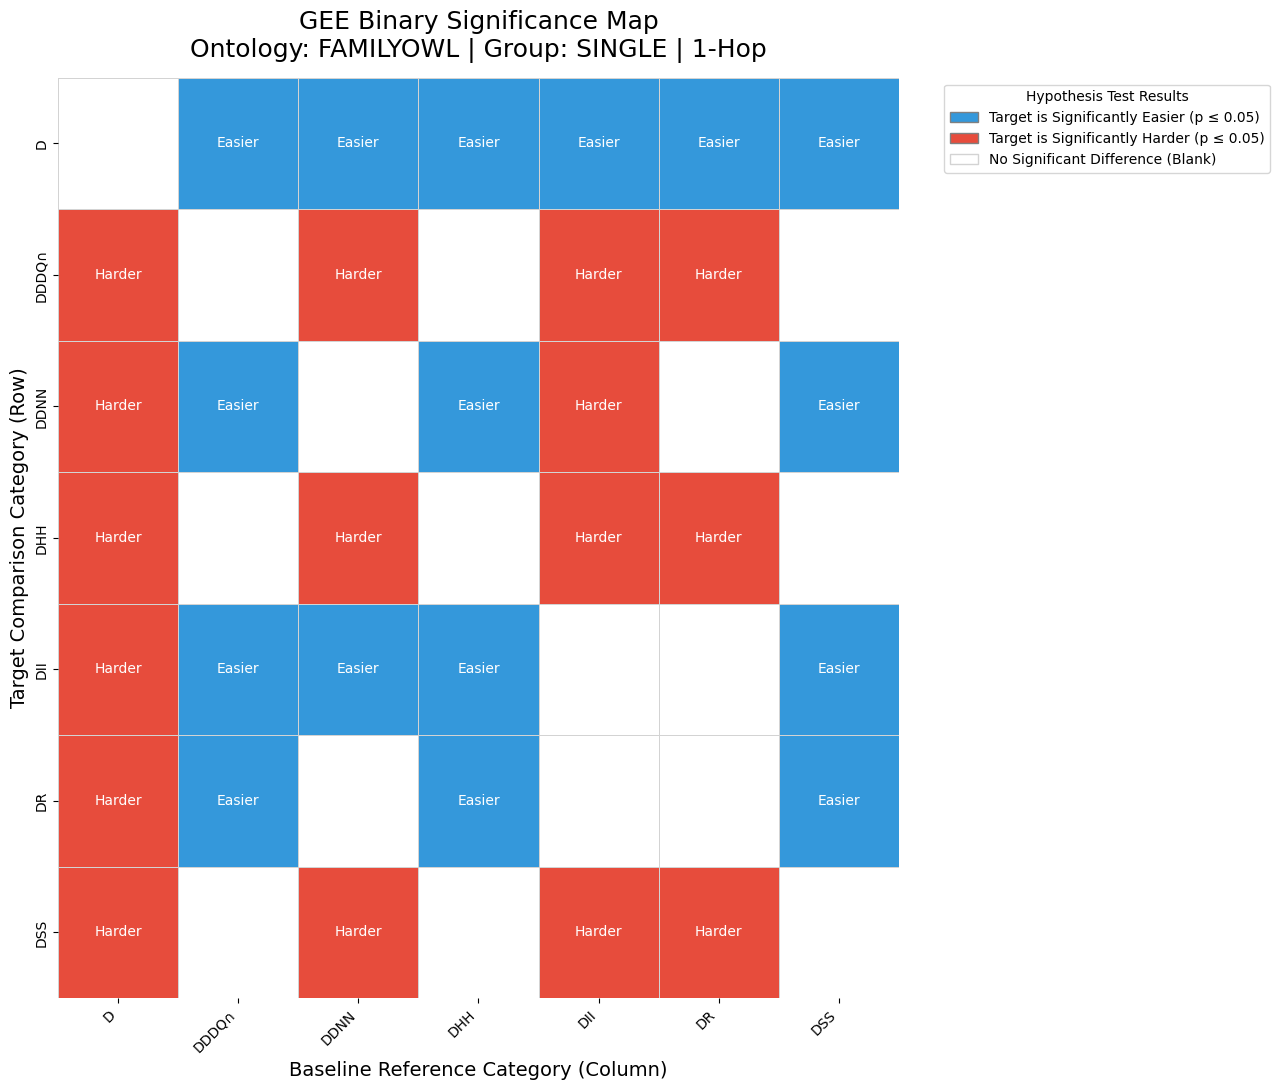

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_FamilyOWL_single_1hop.png
--------------------------------------------------------------------------------
Running baseline rotation loops for Ontology: FAMILYOWL (SINGLE | 2-Hop)...


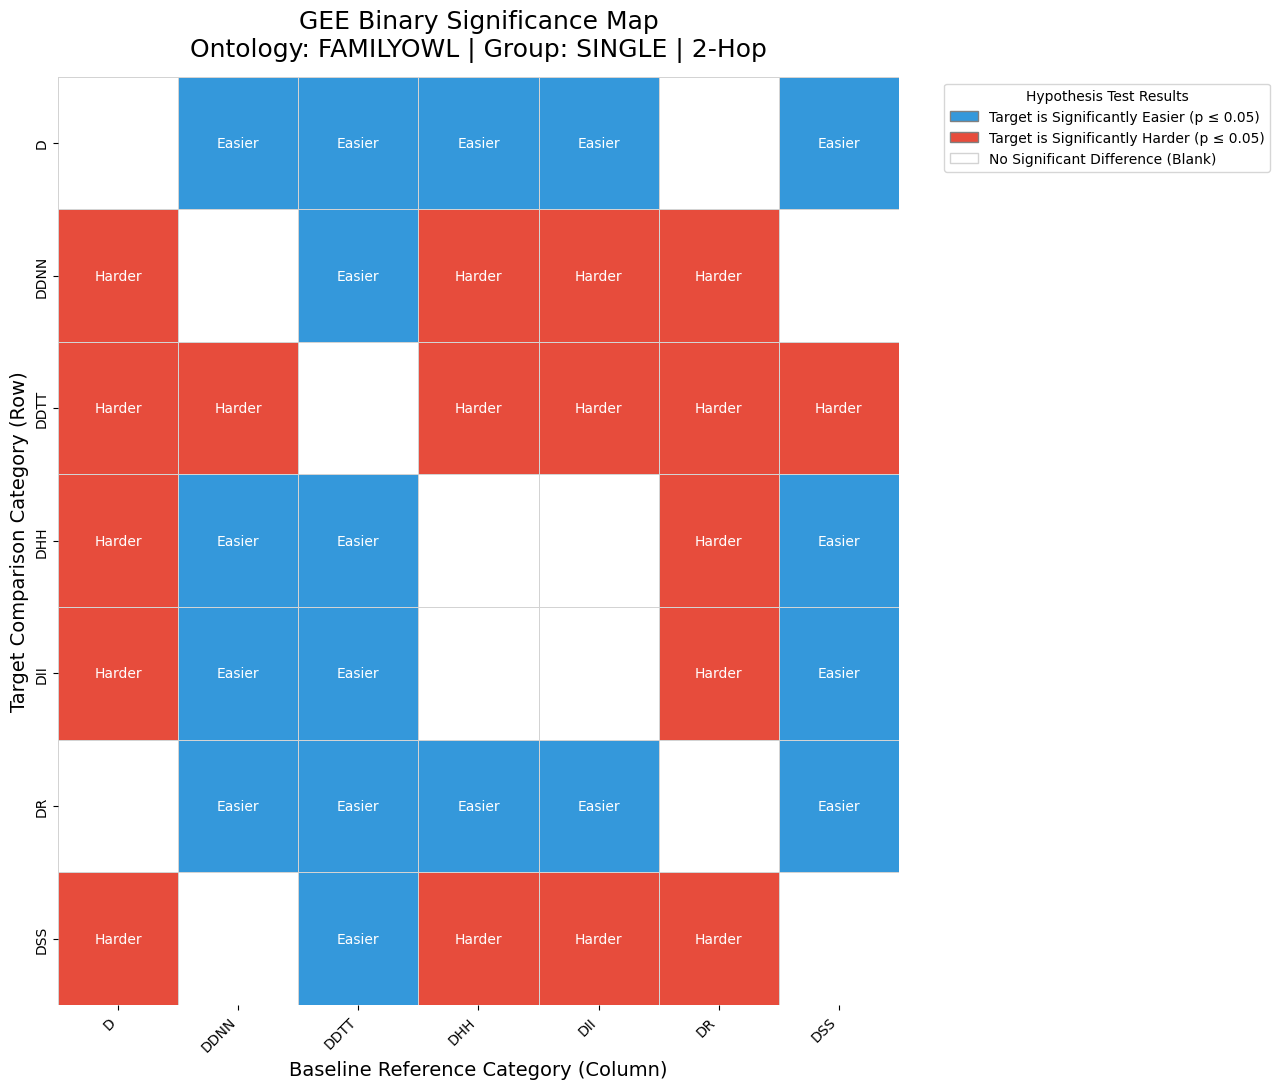

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_FamilyOWL_single_2hop.png
--------------------------------------------------------------------------------
Running baseline rotation loops for Ontology: OWL2BENCH (SINGLE | 1-Hop)...


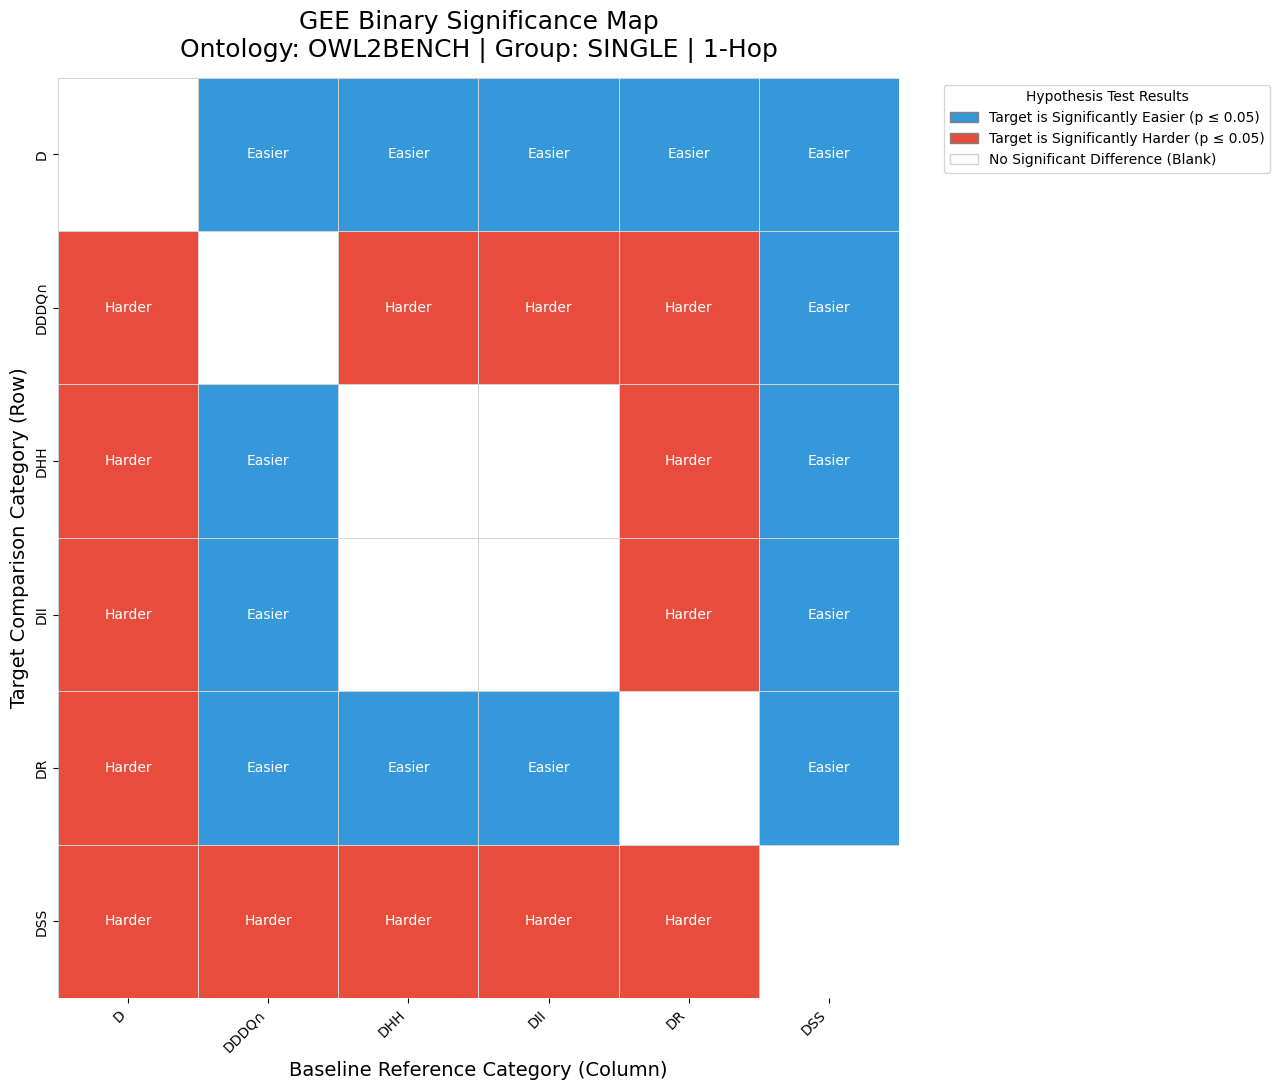

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_OWL2Bench_single_1hop.png
--------------------------------------------------------------------------------
Running baseline rotation loops for Ontology: OWL2BENCH (SINGLE | 2-Hop)...


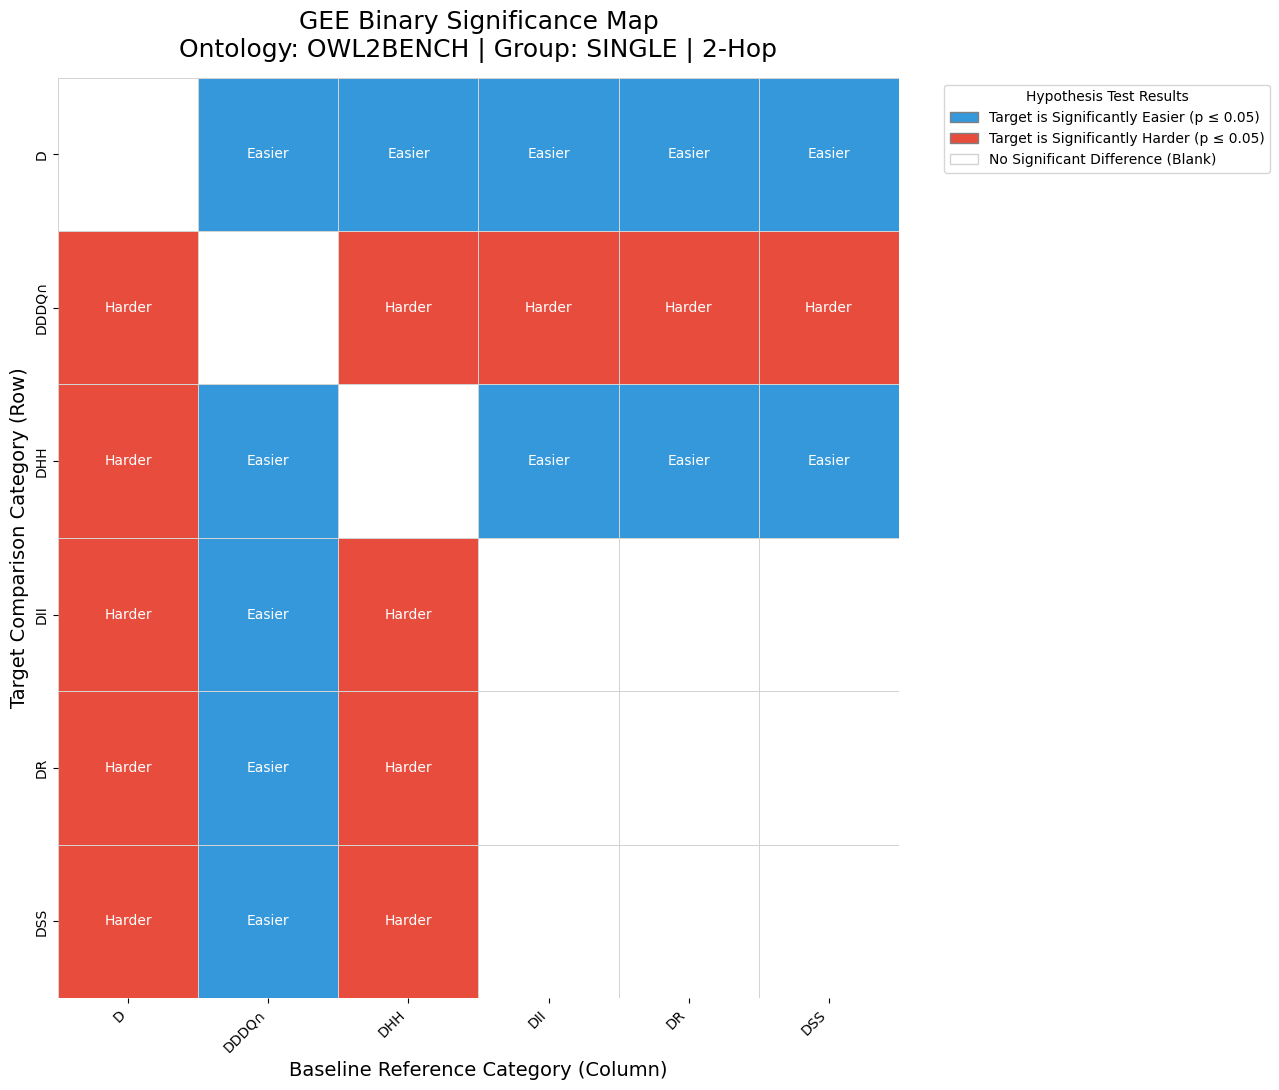

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_OWL2Bench_single_2hop.png
--------------------------------------------------------------------------------
Running baseline rotation loops for Ontology: FAMILYOWL (MULTI | 1-Hop)...


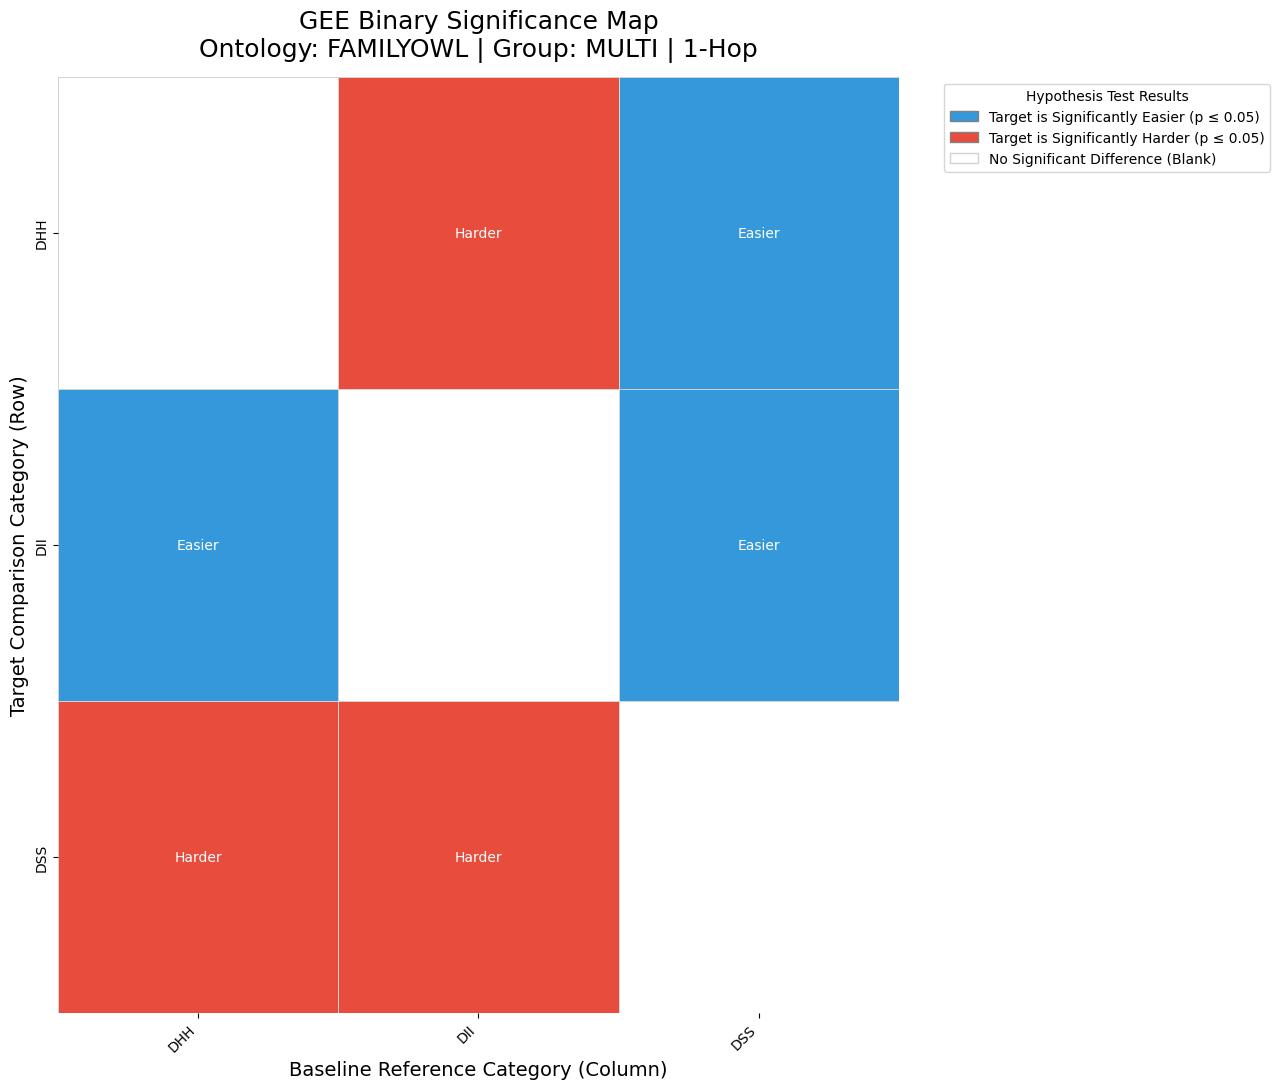

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_FamilyOWL_multi_1hop.png
--------------------------------------------------------------------------------
Running baseline rotation loops for Ontology: FAMILYOWL (MULTI | 2-Hop)...


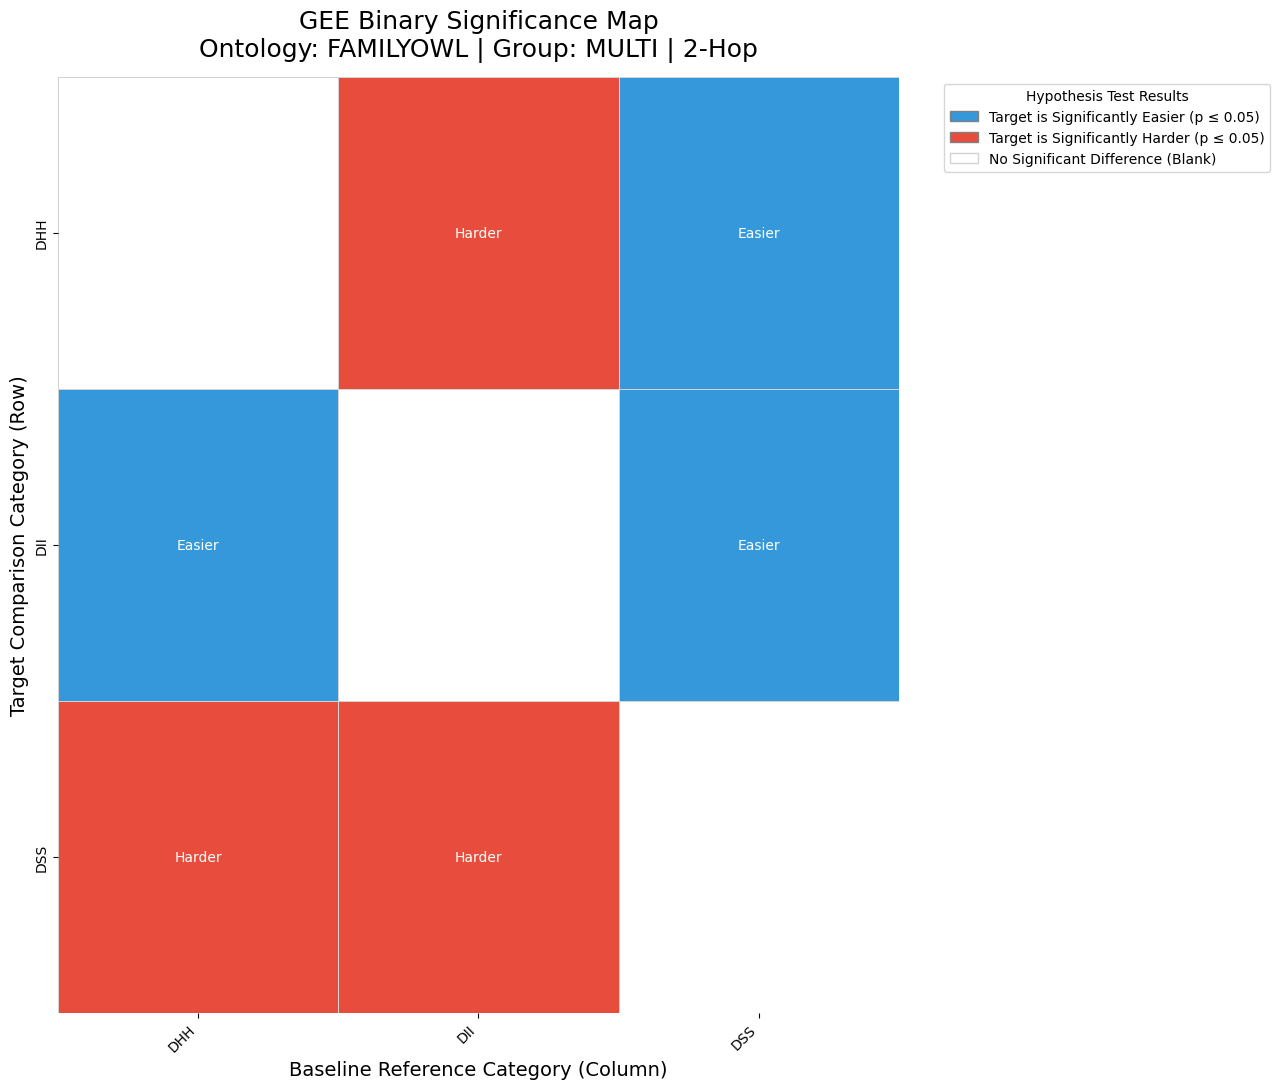

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_FamilyOWL_multi_2hop.png
--------------------------------------------------------------------------------
Running baseline rotation loops for Ontology: OWL2BENCH (MULTI | 1-Hop)...


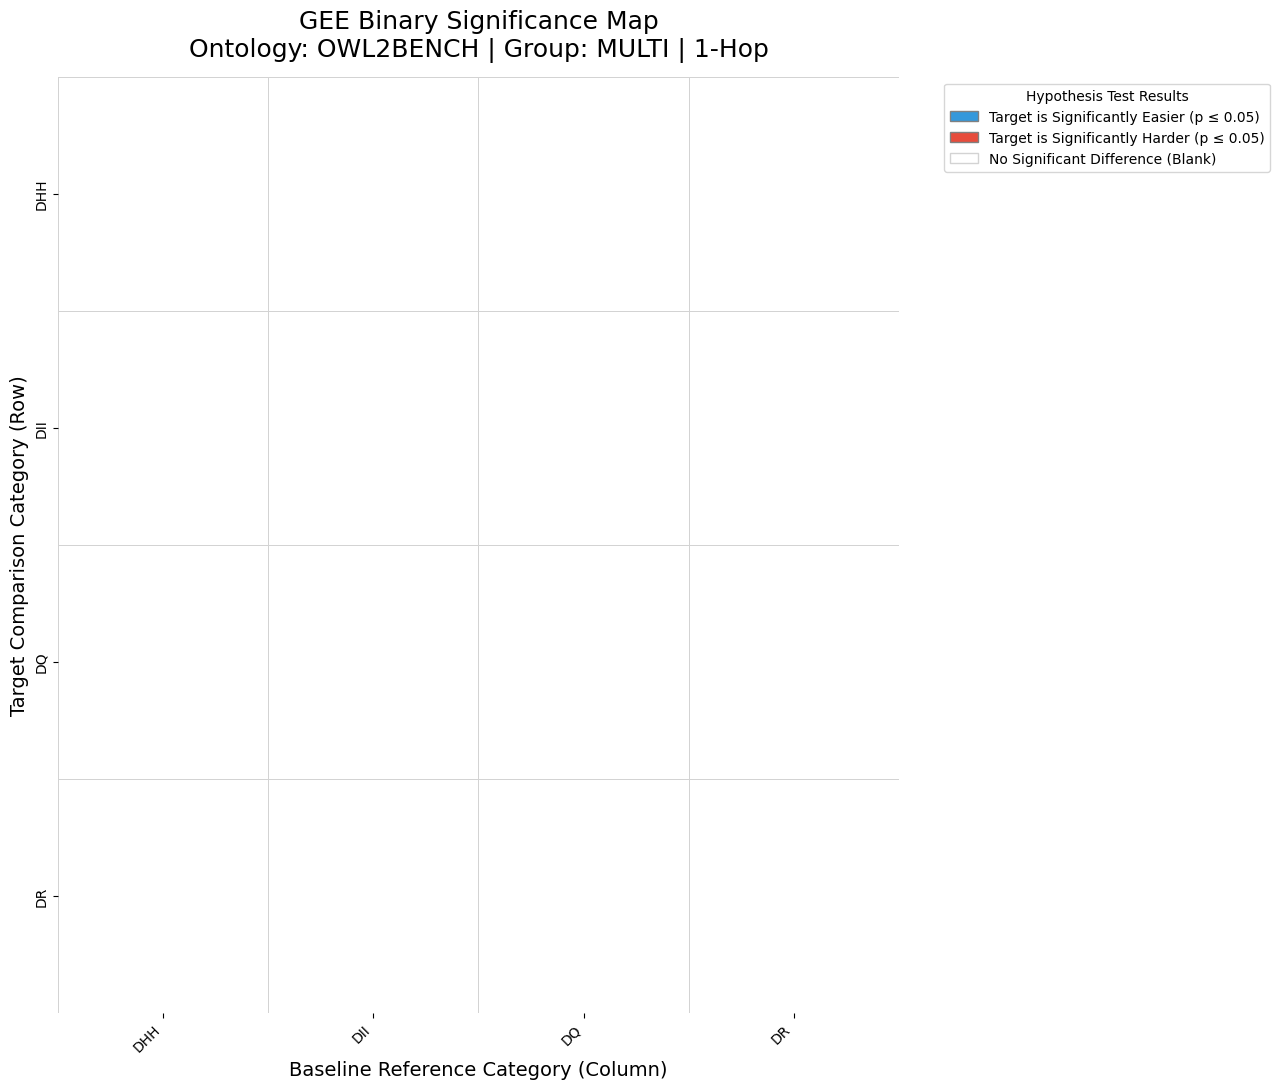

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_OWL2Bench_multi_1hop.png
--------------------------------------------------------------------------------
Running baseline rotation loops for Ontology: OWL2BENCH (MULTI | 2-Hop)...


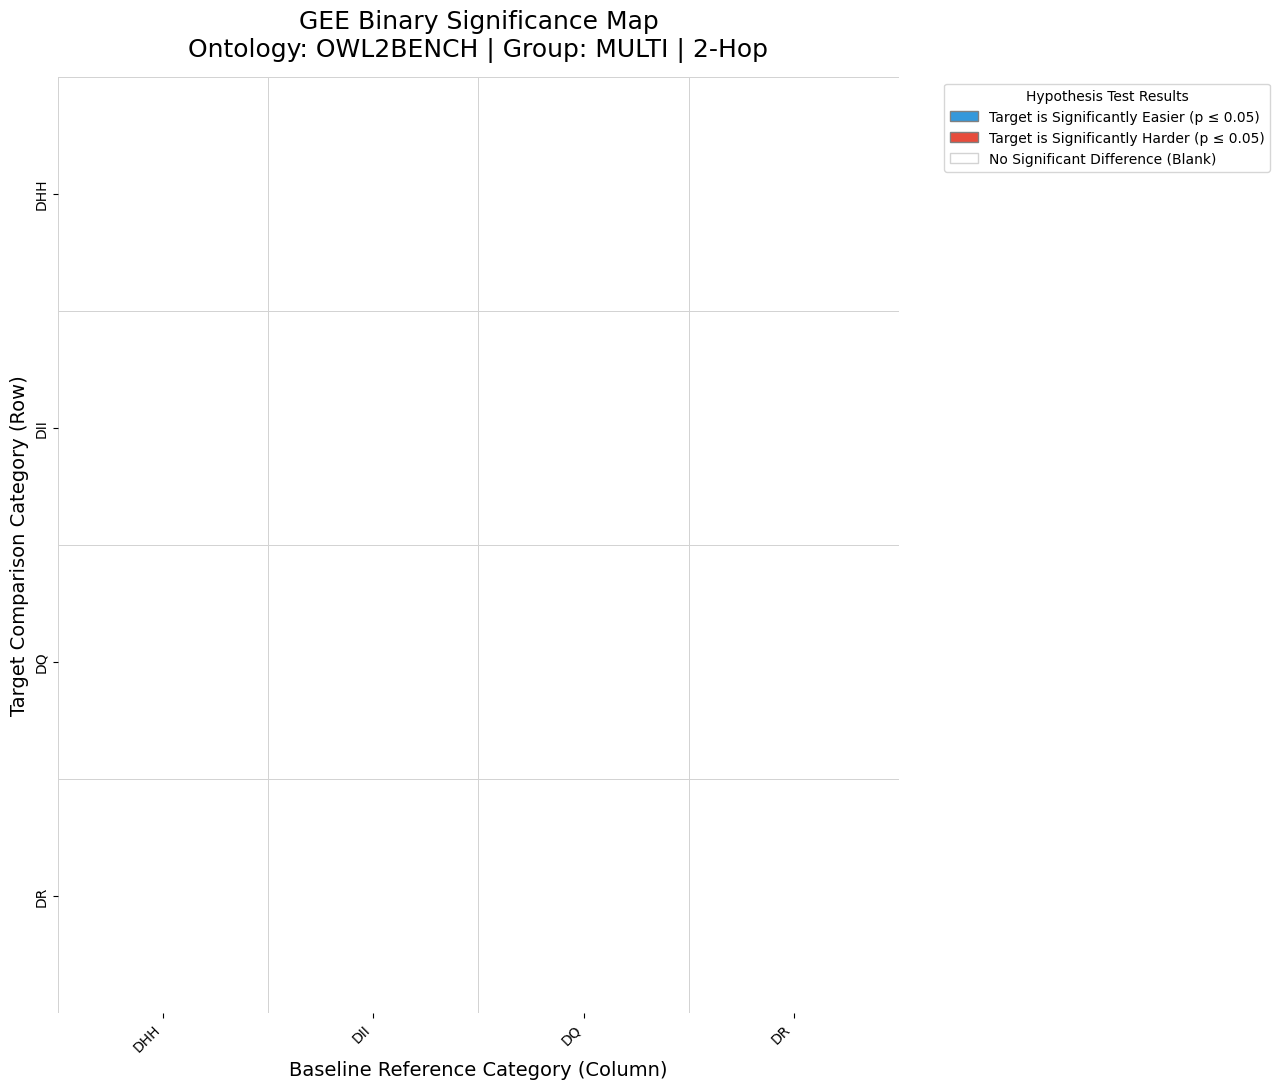

SUCCESS: Binary heatmap saved to C:\Users\migue\Downloads\gee_binary_heatmap_OWL2Bench_multi_2hop.png
--------------------------------------------------------------------------------


In [42]:
import os
import json
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')
base_dir = "../../" 

# --- CONFIGURATION (EXPLICIT PATHS) ---
expl_files = [
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "output", "toy_example", "1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "output", "toy_example", "1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "Explanations.json"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "Explanations.json"),
    os.path.join(base_dir, "data", "output", "toy_example", "1hop", "Explanations.json"),
]

csv_files = [
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "toy_example_1hop", "ttl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "toy_example_1hop", "nl_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_1hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "FamilyOWL_2hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_1hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "OWL2Bench_2hop", "abstract_results_FINAL.csv"),
    os.path.join(base_dir, "data", "results", "toy_example_1hop", "abstract_results_FINAL.csv"),
]

downloads_dir = os.path.abspath(os.path.expanduser("~/Downloads"))
os.makedirs(downloads_dir, exist_ok=True)

# --- CLEANING AND LOADING UTILITIES ---
def clean_answer(text):
    if pd.isna(text): return set()
    text = str(text).strip().lower()
    parts = re.split(r'[;,]', text)
    cleaned_set = set()
    for part in parts:
        part = re.sub(r'[_*#@$%^&()+={\[\]}\|\\:;"\'<>?/~`]', '', part)
        part = re.sub(r'\s\d{4}$', '', part)
        part = re.sub(r'\b\d+\b', '', part)
        part = re.sub(r'[^a-z0-9\s]', '', part).strip()
        if part: cleaned_set.add(part)
    return cleaned_set

def get_jaccard_score(expected, actual, q_type="MC"):
    set_expected = clean_answer(expected)
    set_actual = clean_answer(actual)
    if not set_expected and not set_actual: return 0.0
    intersection = len(set_expected.intersection(set_actual))
    union = len(set_expected.union(set_actual))
    if union == 0: return 0.0
    score = intersection / union
    if q_type == "BIN": return 1.0 if score == 1.0 else 0.0
    return score

def load_explanations(filepath):
    task_to_tags = defaultdict(set)
    if not os.path.exists(filepath): return task_to_tags
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
        for details in data.values():
            task_ids = details.get("taskIds", []) or []
            explanations = details.get("explanations", []) or []
            path_tags = []
            for exp_list in explanations:
                for item in exp_list:
                    if isinstance(item, str) and item.startswith("TAG:"):
                        path_tags.append(item.replace("TAG:", "").strip())
            for tid in task_ids:
                task_to_tags[str(tid)].update(path_tags)
    return task_to_tags

# --- PHASE 1: DATA COMPILATION ---
rows_collector = []

for csv_file, expl_file in zip(csv_files, expl_files):
    if "toy_example" in csv_file: continue
    if not os.path.exists(csv_file) or not os.path.exists(expl_file): continue
        
    parent_dir = os.path.basename(os.path.dirname(csv_file))
    csv_name = os.path.basename(csv_file)
    ontology = re.sub(r'_[12]hop', '', parent_dir)
    hop_num = int(re.search(r'([12])hop', parent_dir).group(1)) if re.search(r'([12])hop', parent_dir) else 1
    syntax_type = "ttl" if "ttl" in csv_name else "nl" if "nl" in csv_name else "abstract"
    
    task_to_tags = load_explanations(expl_file)
    df = pd.read_csv(csv_file)
    
    if 'Task ID' not in df.columns: continue
    correctness_cols = [col for col in df.columns if col.endswith('_quality_correctness')]
    
    for col in correctness_cols:
        model_name = col.replace('_quality_correctness', '')
        final_ans_col = f"{model_name}_final_answer"
        
        for _, row in df.iterrows():
            tid = str(row['Task ID']).strip()
            if tid not in task_to_tags or not task_to_tags[tid]: continue
            
            unique_tags = task_to_tags[tid]
            min_len_task = min(len(t) for t in unique_tags)
            shortest_tags_task = [t for t in unique_tags if len(t) == min_len_task]
            group_type = "multi" if len(shortest_tags_task) > 1 else "single"
            
            if final_ans_col in df.columns and 'Answer' in df.columns:
                prediction = str(row[final_ans_col]).strip()
                if pd.isna(row[final_ans_col]) or prediction == "" or prediction.upper().startswith("ERROR"):
                    continue
                jaccard_accuracy = get_jaccard_score(row['Answer'], row[final_ans_col], row.get('Question Type', 'MC'))
            else:
                corr = row[col]
                if pd.isna(corr): continue
                jaccard_accuracy = 1.0 if int(float(corr)) == 1 else 0.0
            
            for target_tag in shortest_tags_task:
                rows_collector.append({
                    "task_id": tid,
                    "model": model_name,
                    "ontology": ontology,
                    "syntax": syntax_type,
                    "hop_count": hop_num,
                    "tag_type": target_tag, 
                    "group": group_type,
                    "jaccard_accuracy": jaccard_accuracy
                })

stats_df = pd.DataFrame(rows_collector)
print(f"Data Collection Complete. Collected {len(stats_df)} row observations.")

# --- PHASE 2: COMBINATORIAL GEE ROTATION LOOP ---
target_model_baseline = 'gpt-5-mini'

for current_group in ['single', 'multi']:
    for ont in stats_df['ontology'].unique():
        for current_hop in [1, 2]:
            
            # Slicing matching coordinate grid
            grid_data = stats_df[(stats_df['ontology'] == ont) & 
                                 (stats_df['group'] == current_group) & 
                                 (stats_df['hop_count'] == current_hop)].copy()
            
            if grid_data.empty: 
                print(f"Skipping {ont.upper()} | {current_group.upper()} | {current_hop}-Hop: No data.")
                continue
                
            tag_counts = grid_data['tag_type'].value_counts()
            valid_tags = sorted(list(tag_counts[tag_counts >= 5].index))
            if len(valid_tags) < 2: 
                print(f"Skipping {ont.upper()} | {current_group.upper()} | {current_hop}-Hop: Insufficient tag variety after frequency filtering.")
                continue
            
            # Initialize empty matrices to collect coefficients and p-values
            matrix_size = len(valid_tags)
            coef_matrix = pd.DataFrame(np.zeros((matrix_size, matrix_size)), index=valid_tags, columns=valid_tags)
            pval_matrix = pd.DataFrame(np.ones((matrix_size, matrix_size)), index=valid_tags, columns=valid_tags)

            print(f"Running baseline rotation loops for Ontology: {ont.upper()} ({current_group.upper()} | {current_hop}-Hop)...")
            
            for baseline_tag in valid_tags:
                run_data = grid_data.copy()
                run_data['tag_type'] = pd.Categorical(run_data['tag_type'])
                
                # Reorder categories to force the current loop tag as reference baseline
                other_tags = [t for t in valid_tags if t != baseline_tag]
                run_data['tag_type'] = run_data['tag_type'].cat.reorder_categories([baseline_tag] + other_tags)
                
                # Reorder baseline model selection
                run_data['model'] = pd.Categorical(run_data['model'])
                matching_models = [c for c in run_data['model'].cat.categories if target_model_baseline in str(c).lower()]
                if matching_models:
                    chosen_model = matching_models[0]
                    other_models = [m for m in run_data['model'].cat.categories if m != chosen_model]
                    run_data['model'] = run_data['model'].cat.reorder_categories([chosen_model] + other_models)
                
                run_data = run_data.sort_values(by="task_id").reset_index(drop=True)
                
                # hop_count removed from formula since it is now a constant within this grid slice
                formula_parts = ["C(tag_type)", "C(model)"]
                if len(run_data['syntax'].unique()) > 1: formula_parts.append("C(syntax)")
                
                formula = f"jaccard_accuracy ~ {' + '.join(formula_parts)}"
                
                try:
                    model = smf.gee(formula, groups="task_id", data=run_data, 
                                    family=sm.families.Binomial(), 
                                    cov_struct=sm.cov_struct.Exchangeable())
                    results = model.fit()
                    
                    # Extract coefficients relative to the current baseline row
                    for target_tag in other_tags:
                        param_name = f"C(tag_type)[T.{target_tag}]"
                        if param_name in results.params:
                            coef_matrix.loc[baseline_tag, target_tag] = results.params[param_name]
                            pval_matrix.loc[baseline_tag, target_tag] = results.pvalues[param_name]
                except Exception:
                    pass
            # --- PHASE 3: HEATMAP GENERATION (BINARY SIGNIFICANCE) ---
            from matplotlib.colors import ListedColormap
            from matplotlib.patches import Patch
            
            plt.figure(figsize=(14, 11))
            
            # Map logic: +1 (Easier), -1 (Harder), 0 (Not Significant)
            # Original: rows = baseline, cols = target
            binary_matrix = pd.DataFrame(0, index=coef_matrix.index, columns=coef_matrix.columns)
            binary_matrix[(pval_matrix <= 0.05) & (coef_matrix > 0)] = 1
            binary_matrix[(pval_matrix <= 0.05) & (coef_matrix < 0)] = -1
            
            # TRANSPOSE the matrix to put Baseline on the X-axis (columns)
            binary_matrix = binary_matrix.T
            
            # Mask out the non-significant relationships
            significance_mask = (binary_matrix == 0)
            
            # Custom discrete colormap: Red for Harder (-1), Blue for Easier (+1)
            cmap_discrete = ListedColormap(['#e74c3c', '#3498db']) 
            
            # Text annotations instead of numbers
            annot_matrix = np.where(binary_matrix == 1, "Easier", 
                                    np.where(binary_matrix == -1, "Harder", ""))
            
            sns.heatmap(
                binary_matrix,
                mask=significance_mask,
                annot=annot_matrix,
                fmt="",           # Required to allow string annotations
                cmap=cmap_discrete,
                vmin=-1, vmax=1,  # Lock the scale to exactly our two active values
                linewidths=0.5,
                linecolor='lightgray',
                cbar=False        # Remove the continuous gradient bar
            )
            
            # Build a clear, semantic legend
            legend_elements = [
                Patch(facecolor='#3498db', edgecolor='gray', label='Target is Significantly Easier (p \u2264 0.05)'),
                Patch(facecolor='#e74c3c', edgecolor='gray', label='Target is Significantly Harder (p \u2264 0.05)'),
                Patch(facecolor='white', edgecolor='lightgray', label='No Significant Difference (Blank)')
            ]
            plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.45, 1.0), title="Hypothesis Test Results")
            
            plt.title(f"GEE Binary Significance Map\nOntology: {ont.upper()} | Group: {current_group.upper()} | {current_hop}-Hop", fontsize=18, pad=15)
            
            # SWAPPED AXIS LABELS
            plt.ylabel("Target Comparison Category (Row)", fontsize=14)
            plt.xlabel("Baseline Reference Category (Column)", fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            
            export_name = f"gee_binary_heatmap_{ont}_{current_group}_{current_hop}hop.png"
            export_path = os.path.join(downloads_dir, export_name)
            plt.savefig(export_path, dpi=150)
            plt.show()
            print(f"SUCCESS: Binary heatmap saved to {export_path}\n" + "-"*80)